# API Performance Analysis — Pipetly Multi-API Search Pipeline

This notebook evaluates the performance and data quality of the **Pipetly** multi-API paper search pipeline across all stages: `paper_searcher` (Step 2), `metadata_filter` (Step 2→3), `full_text_retriever` (Step 4), and `text_extractor` (Step 5).

**Analyses covered:**
1. Search Coverage by API (queries only) — which APIs yield the most DOI-bearing records?
2. API Contribution & Uniqueness Score — how exclusive is each API's contribution?
3. DOI Overlap Heatmap — cross-API redundancy at a glance
4. Latency & Reliability — response-time distributions and error rates
5. Metadata Quality Audit — missing-field rates per API
6. Filtering Funnel — paper counts lost at each pipeline stage
7. Full-Text Retrieval Utility per source API — success rate broken down by the API that found each paper
8. Full-Text Retrieval Utility per full-text API — coverage, quality and content size by retrieval client (Step 4)
9. Full-Text Retrieval Speed — response-time distribution per retrieval client (Step 4)


## 1. Import Libraries & Configuration

In [22]:
import json
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# -- Styling -------------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

# -- Paths ---------------------------------------------------------------------
BASE = Path("..")  # notebook lives inside notebooks/
IO = BASE / "intermediate_outputs"


def _resolve_intermediate(*names: str) -> Path:
    for name in names:
        path = IO / name
        if path.exists():
            return path
    return IO / names[0]


STEP1 = IO / "step1_expanded_query.json"
STEP2 = IO / "step2_raw_papers.json"
STEP3 = _resolve_intermediate(
    "step3_doi_filtered_papers.json",
    "step3_filtered_papers.json",
)
STEP4 = IO / "step4_fulltext_raw_papers.json"
STEP5 = IO / "step5_fulltext_clean_papers.json"

# Known API label ordering (for consistent chart ordering)
API_ORDER = [
    "openalex",
    "crossref",
    "semantic_scholar",
    "scopus",
    "elsevier",
    "pmc",
    "europe_pmc",
]

# API display names (search/source APIs)
API_LABELS = {
    "openalex": "OpenAlex",
    "crossref": "CrossRef",
    "semantic_scholar": "Semantic Scholar",
    "scopus": "Scopus",
    "elsevier": "Elsevier",
    "pmc": "PMC",
    "europe_pmc": "Europe PMC",
}

# Full-text retrieval client display names (active clients only)
CLIENT_LABELS = {
    "europe_pmc": "Europe PMC",
    "pmc": "PMC",
    "elsevier": "Elsevier",
    "semantic_scholar": "Semantic Scholar",
    "unpaywall": "Unpaywall",
}

print("Libraries loaded. Base path:", BASE.resolve())
print("Resolved Step 3 file:", STEP3.name)

Libraries loaded. Base path: C:\Users\rebec\OneDrive\Documentos\TFM\repo\Pipetly_Paper\Pipetly
Resolved Step 3 file: step3_doi_filtered_papers.json


## 2. Load Query Data from `step1_expanded_query.json`

In [23]:
with open(STEP1, encoding="utf-8") as fh:
    query_data = json.load(fh)

intent = query_data.get("intent", "")
queries = query_data.get("queries", [])

print(f"Intent: {intent}\n")
summary = pd.DataFrame(
    {
        "strategy": ["queries"],
        "query_count": [len(queries)],
        "example": [queries[0] if queries else ""],
    }
)
print(summary.to_string(index=False))

Intent: Protocols for FmtA protein crystallization for X-ray crystallography.

strategy  query_count              example
 queries            5 FmtA crystallization


## 3. Query Effectiveness — per API (queries only)

The current pipeline generates only `queries`, and Step 2 search runs exclusively with that strategy.

The table and heatmap below show DOI yield per API for this single query strategy.

In [24]:
with open(STEP2, encoding="utf-8") as fh:
    step2_data = json.load(fh)
    raw_papers = step2_data.get("papers", step2_data) if isinstance(step2_data, dict) else step2_data

QUERY_TYPES = ["queries"]
apis_present = [a for a in API_ORDER if a in {p.get("source") for p in raw_papers}]

print(f"APIs found in data               : {apis_present}\n")

doi_matrix = pd.DataFrame(np.nan, index=apis_present, columns=QUERY_TYPES)
total_matrix = pd.DataFrame(np.nan, index=apis_present, columns=QUERY_TYPES)

for paper in raw_papers:
    src = paper.get("source", "unknown")
    qt = "queries"
    if src not in apis_present:
        continue
    if pd.isna(total_matrix.at[src, qt]):
        total_matrix.at[src, qt] = 0
        doi_matrix.at[src, qt] = 0
    total_matrix.at[src, qt] += 1
    if paper.get("doi"):
        doi_matrix.at[src, qt] += 1

doi_matrix.index = [API_LABELS.get(a, a) for a in apis_present]
total_matrix.index = [API_LABELS.get(a, a) for a in apis_present]

summary_rows = []
for qt in QUERY_TYPES:
    col = doi_matrix[qt].dropna()
    summary_rows.append(
        {
            "Strategy": qt,
            "APIs tested": int(col.count()),
            "Total DOIs found": int(col.sum()),
            "Avg DOIs / API": round(col.mean(), 1) if len(col) else 0,
            "Best API": col.idxmax() if len(col) else "—",
        }
    )
df_strat_summary = pd.DataFrame(summary_rows).set_index("Strategy")

print("Analysis mode: queries-only\n")
display(df_strat_summary)

APIs found in data               : ['openalex', 'crossref', 'semantic_scholar', 'scopus', 'elsevier', 'europe_pmc']

Analysis mode: queries-only



,APIs tested,Total DOIs found,Avg DOIs / API,Best API
Strategy,,,,
queries,6,29,4.8,OpenAlex


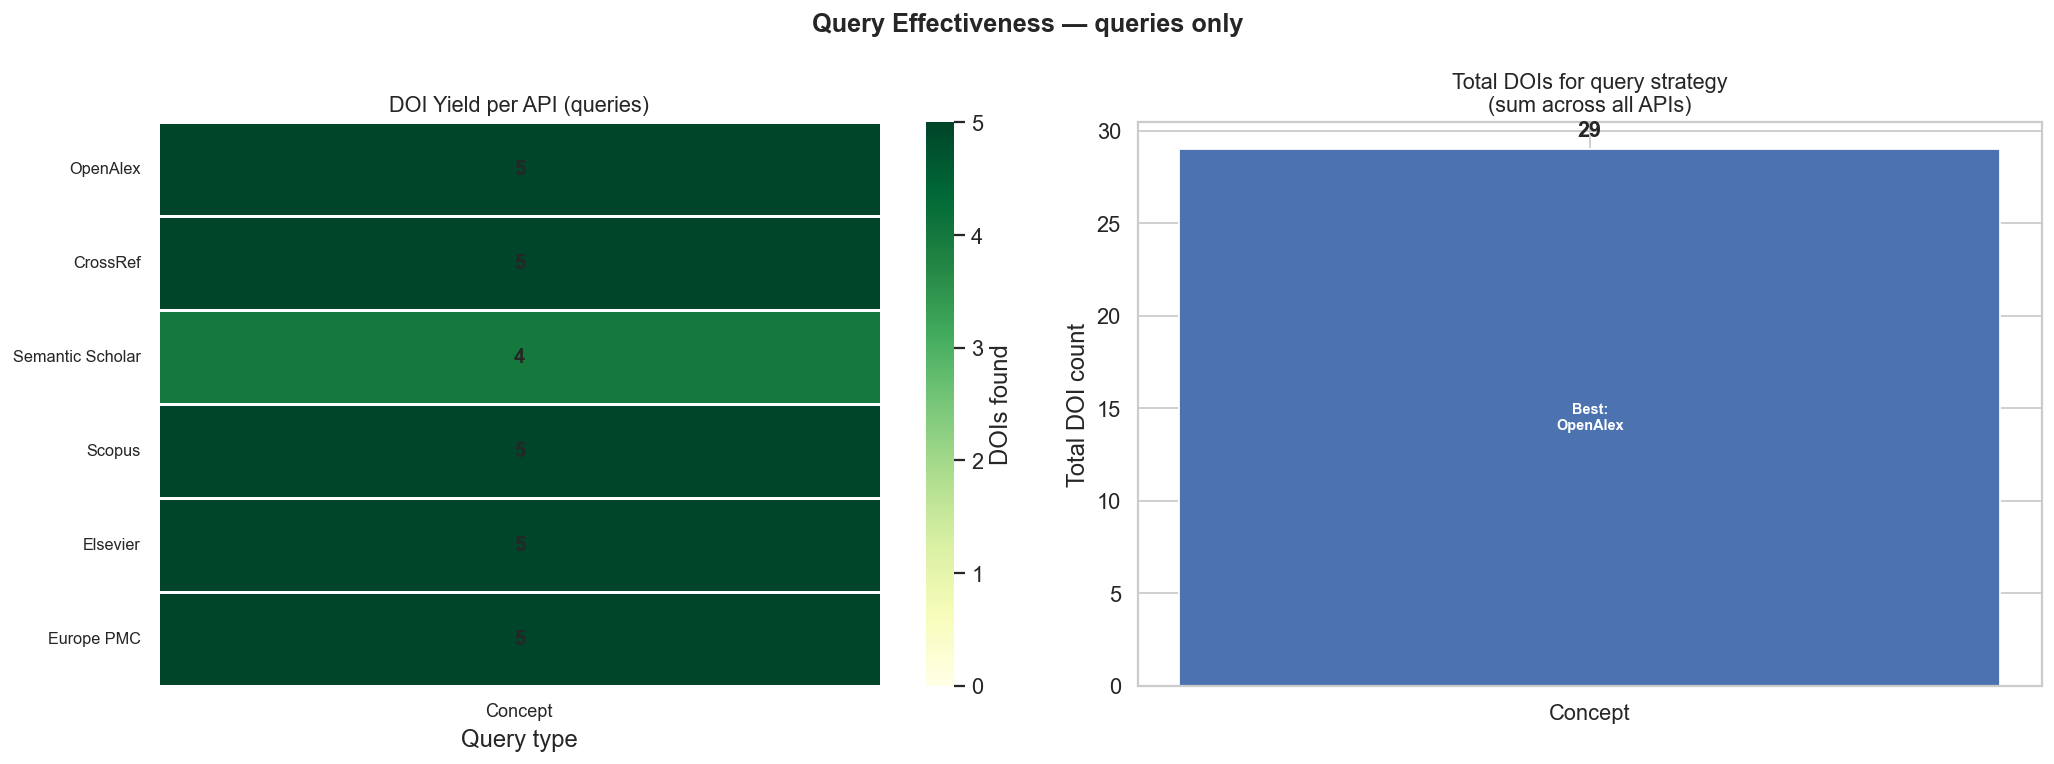


✔  Strategy with highest DOI yield: 'Concept' (29 DOIs)


In [25]:
short_qt = {"queries": "Concept"}
doi_matrix_plot = doi_matrix.rename(columns=short_qt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: DOI yield per API for concept strategy
ax = axes[0]
mask_nan = doi_matrix_plot.isna()
plot_data = doi_matrix_plot.fillna(-1)

sns.heatmap(
    plot_data,
    annot=False,
    cmap="YlGn",
    vmin=0,
    vmax=max(doi_matrix_plot.max().max(), 1),
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "DOIs found"},
    mask=mask_nan,
)

for i, _ in enumerate(doi_matrix_plot.index):
    for j, _ in enumerate(doi_matrix_plot.columns):
        val = doi_matrix_plot.iloc[i, j]
        if pd.isna(val):
            ax.text(
                j + 0.5,
                i + 0.5,
                "—",
                ha="center",
                va="center",
                fontsize=11,
                color="#aaaaaa",
            )
        else:
            ax.text(
                j + 0.5,
                i + 0.5,
                str(int(val)),
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
            )

ax.set_title("DOI Yield per API (queries)", fontsize=12)
ax.set_xlabel("Query type")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# Right: total DOI count for current strategy
ax2 = axes[1]
strategy_totals = doi_matrix_plot.sum(skipna=True)
bars = ax2.bar(
    strategy_totals.index, strategy_totals.values, color=["#4C72B0"], width=0.5
)
ax2.set_title("Total DOIs for query strategy\n(sum across all APIs)", fontsize=12)
ax2.set_ylabel("Total DOI count")
for bar, val in zip(bars, strategy_totals.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(val)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

for bar, qt_short in zip(bars, strategy_totals.index):
    col = doi_matrix_plot[qt_short].dropna()
    if len(col):
        best = col.idxmax()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f"Best:\n{best}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )

fig.suptitle(
    "Query Effectiveness — queries only", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

best_strat = strategy_totals.idxmax()
print(
    f"\n✔  Strategy with highest DOI yield: '{best_strat}' ({int(strategy_totals[best_strat])} DOIs)"
)

## 4. API Contribution & Uniqueness Score

This section provides a **dual-level redundancy analysis** of each API's raw output.

| Level | Description |
|---|---|
| **Intra-API Redundancy (Internal Noise)** | Papers returned more than once by the same API — detected by a repeated DOI, or by identical normalised title with a different DOI (e.g. preprint vs. published version). Papers without a DOI and without a matching title are also counted as uncategorised noise. |
| **Inter-API Redundancy (External Overlap)** | Papers whose DOI is also returned by at least one other API. |
| **Uniqueness** | DOIs retrieved exclusively by this API and no other. |

The stacked bar chart shows these three categories as **% of each API's total raw output**. A tall green segment means the API brings genuinely new content; a tall red segment means it mostly produces internal duplicates or uncategorisable records.

In [26]:
# ── Build per-API DOI sets (overall) ─────────────────────────────────────────
api_doi_sets: dict[str, set] = defaultdict(set)
api_counts: dict[str, int] = defaultdict(int)

for paper in raw_papers:
    src = paper.get("source", "unknown")
    doi = paper.get("doi")
    api_counts[src] += 1
    if doi:
        api_doi_sets[src].add(doi.lower())

# Universe of all DOIs
all_dois = set()
for dois in api_doi_sets.values():
    all_dois |= dois

# Uniqueness: DOIs found by exactly this API and no other
doi_src_counter = Counter(
    paper["doi"].lower() for paper in raw_papers if paper.get("doi")
)
unique_doi_per_api: dict[str, int] = defaultdict(int)
for paper in raw_papers:
    doi = paper.get("doi")
    if doi and doi_src_counter[doi.lower()] == 1:
        unique_doi_per_api[paper.get("source", "unknown")] += 1

# ── Per-API summary DataFrame ─────────────────────────────────────────────────
df_api = pd.DataFrame(
    {
        "api_name": [API_LABELS.get(a, a) for a in apis_present],
        "total_papers": [api_counts[a] for a in apis_present],
        "dois_found": [len(api_doi_sets[a]) for a in apis_present],
        "unique_dois": [unique_doi_per_api[a] for a in apis_present],
    }
)
df_api["uniqueness_score_pct"] = (
    (df_api["unique_dois"] / df_api["dois_found"].replace(0, np.nan) * 100)
    .fillna(0)
    .round(1)
)

display(
    df_api.sort_values("uniqueness_score_pct", ascending=False).reset_index(drop=True)
)

# ── Dual-level redundancy analysis ───────────────────────────────────────────
import re as _re_r

_ws_r = _re_r.compile(r"\s+")


def _norm_t(t: str) -> str:
    return _ws_r.sub(" ", (t or "").strip().lower())


redundancy_rows = []
for api_key in apis_present:
    api_papers = [p for p in raw_papers if p.get("source") == api_key]
    total = len(api_papers)
    if total == 0:
        continue

    # Detect intra-API duplicates:
    # – same DOI returned multiple times by this API
    # – different DOI but identical normalised title within this API
    doi_seen: dict[str, int] = {}
    title_seen: dict[str, int] = {}
    noise_idx: set[int] = set()

    for idx, p in enumerate(api_papers):
        doi = (p.get("doi") or "").strip().lower()
        title = _norm_t(p.get("title", ""))

        if doi:
            if doi in doi_seen:
                noise_idx.add(idx)  # same DOI again from this API
            else:
                doi_seen[doi] = idx
                if title:
                    if title in title_seen:
                        noise_idx.add(idx)  # same title, different DOI
                    else:
                        title_seen[title] = idx
        else:
            if title:
                if title in title_seen:
                    noise_idx.add(idx)  # no DOI, duplicate title
                else:
                    title_seen[title] = idx
            else:
                noise_idx.add(idx)  # no DOI, no title – useless record

    # Among non-noise papers, split into external-overlap vs unique
    doi_in_others = set()
    for other in apis_present:
        if other != api_key:
            doi_in_others |= api_doi_sets[other]

    n_external = n_unique_red = 0
    for idx, p in enumerate(api_papers):
        if idx in noise_idx:
            continue
        doi = (p.get("doi") or "").strip().lower()
        if not doi:
            noise_idx.add(idx)  # no DOI, fresh title – absorb into noise
            continue
        if doi in doi_in_others:
            n_external += 1
        else:
            n_unique_red += 1

    n_noise = len(noise_idx)

    redundancy_rows.append(
        {
            "API": API_LABELS.get(api_key, api_key),
            "api_key": api_key,
            "total": total,
            "unique": n_unique_red,
            "external_overlap": n_external,
            "internal_noise": n_noise,
            "unique_pct": round(n_unique_red / total * 100, 1),
            "overlap_pct": round(n_external / total * 100, 1),
            "noise_pct": round(n_noise / total * 100, 1),
        }
    )

df_redundancy = (
    pd.DataFrame(redundancy_rows)
    .sort_values("unique_pct", ascending=False)
    .reset_index(drop=True)
)

print("\nDual-level redundancy summary (% of total API output):")
display(
    df_redundancy[
        [
            "API",
            "total",
            "unique",
            "external_overlap",
            "internal_noise",
            "unique_pct",
            "overlap_pct",
            "noise_pct",
        ]
    ]
    .rename(
        columns={
            "unique_pct": "Unique %",
            "overlap_pct": "ExtOverlap %",
            "noise_pct": "IntNoise %",
        }
    )
    .style.background_gradient(subset=["Unique %"], cmap="Greens", vmin=0, vmax=100)
    .background_gradient(subset=["ExtOverlap %"], cmap="Oranges", vmin=0, vmax=100)
    .background_gradient(subset=["IntNoise %"], cmap="Reds", vmin=0, vmax=100)
    .format({"Unique %": "{:.1f}%", "ExtOverlap %": "{:.1f}%", "IntNoise %": "{:.1f}%"})
)

,api_name,total_papers,dois_found,unique_dois,uniqueness_score_pct
0,OpenAlex,5,5,4,80.0
1,CrossRef,5,4,3,75.0
2,Scopus,5,4,3,75.0
3,Semantic Scholar,5,4,2,50.0
4,Europe PMC,5,4,2,50.0
5,Elsevier,5,2,0,0.0



Dual-level redundancy summary (% of total API output):


,API,total,unique,external_overlap,internal_noise,Unique %,ExtOverlap %,IntNoise %
0,OpenAlex,5,4,1,0,80.0%,20.0%,0.0%
1,Scopus,5,4,0,1,80.0%,0.0%,20.0%
2,CrossRef,5,3,1,1,60.0%,20.0%,20.0%
3,Europe PMC,5,3,1,1,60.0%,20.0%,20.0%
4,Semantic Scholar,5,2,2,1,40.0%,40.0%,20.0%
5,Elsevier,5,1,1,3,20.0%,20.0%,60.0%


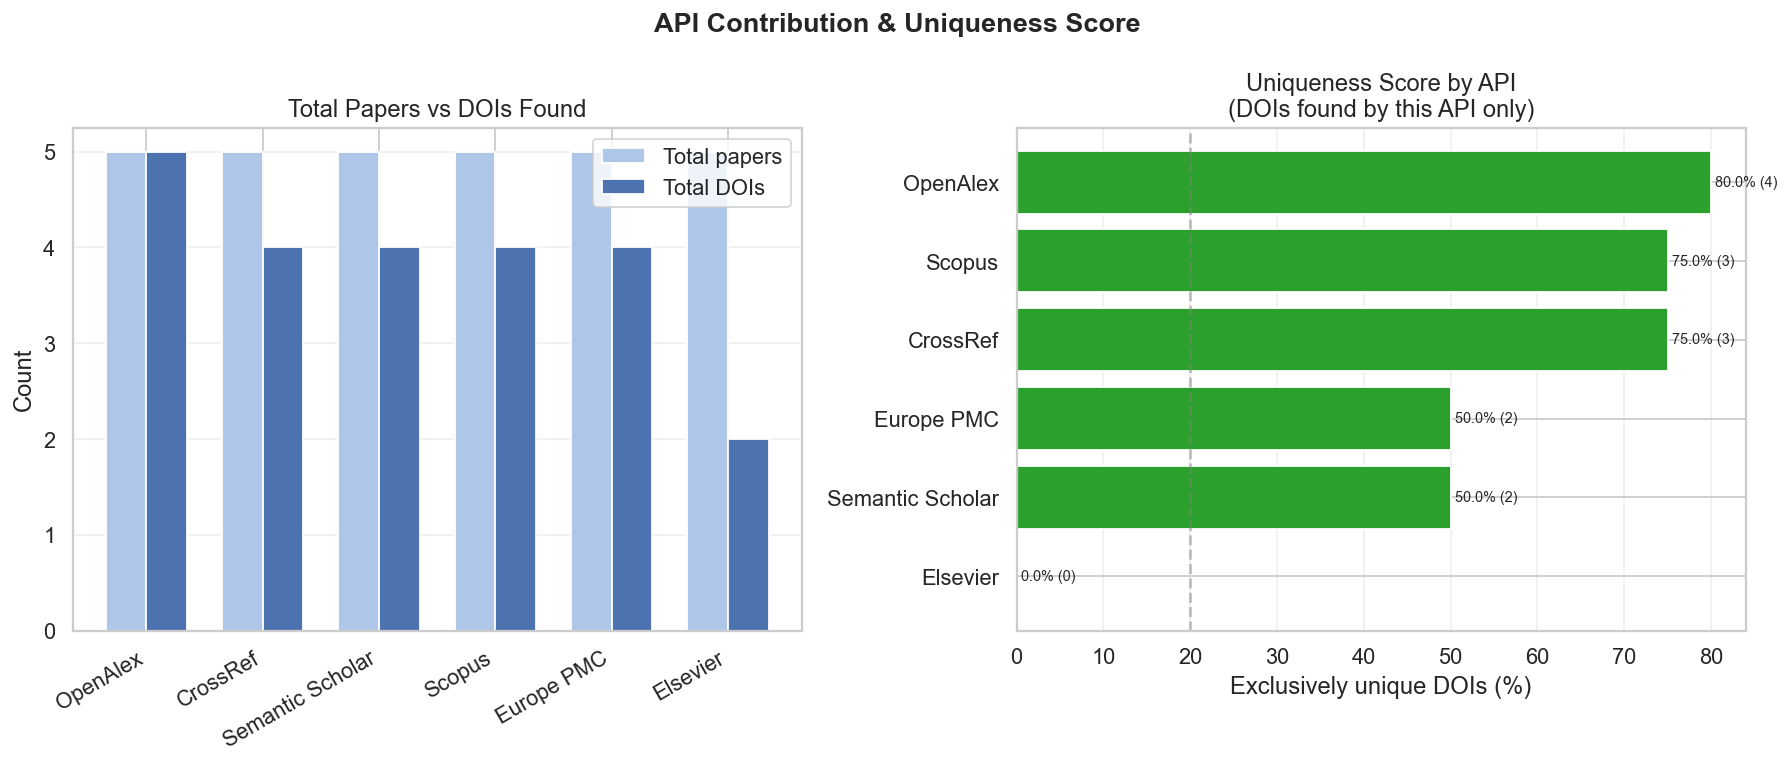

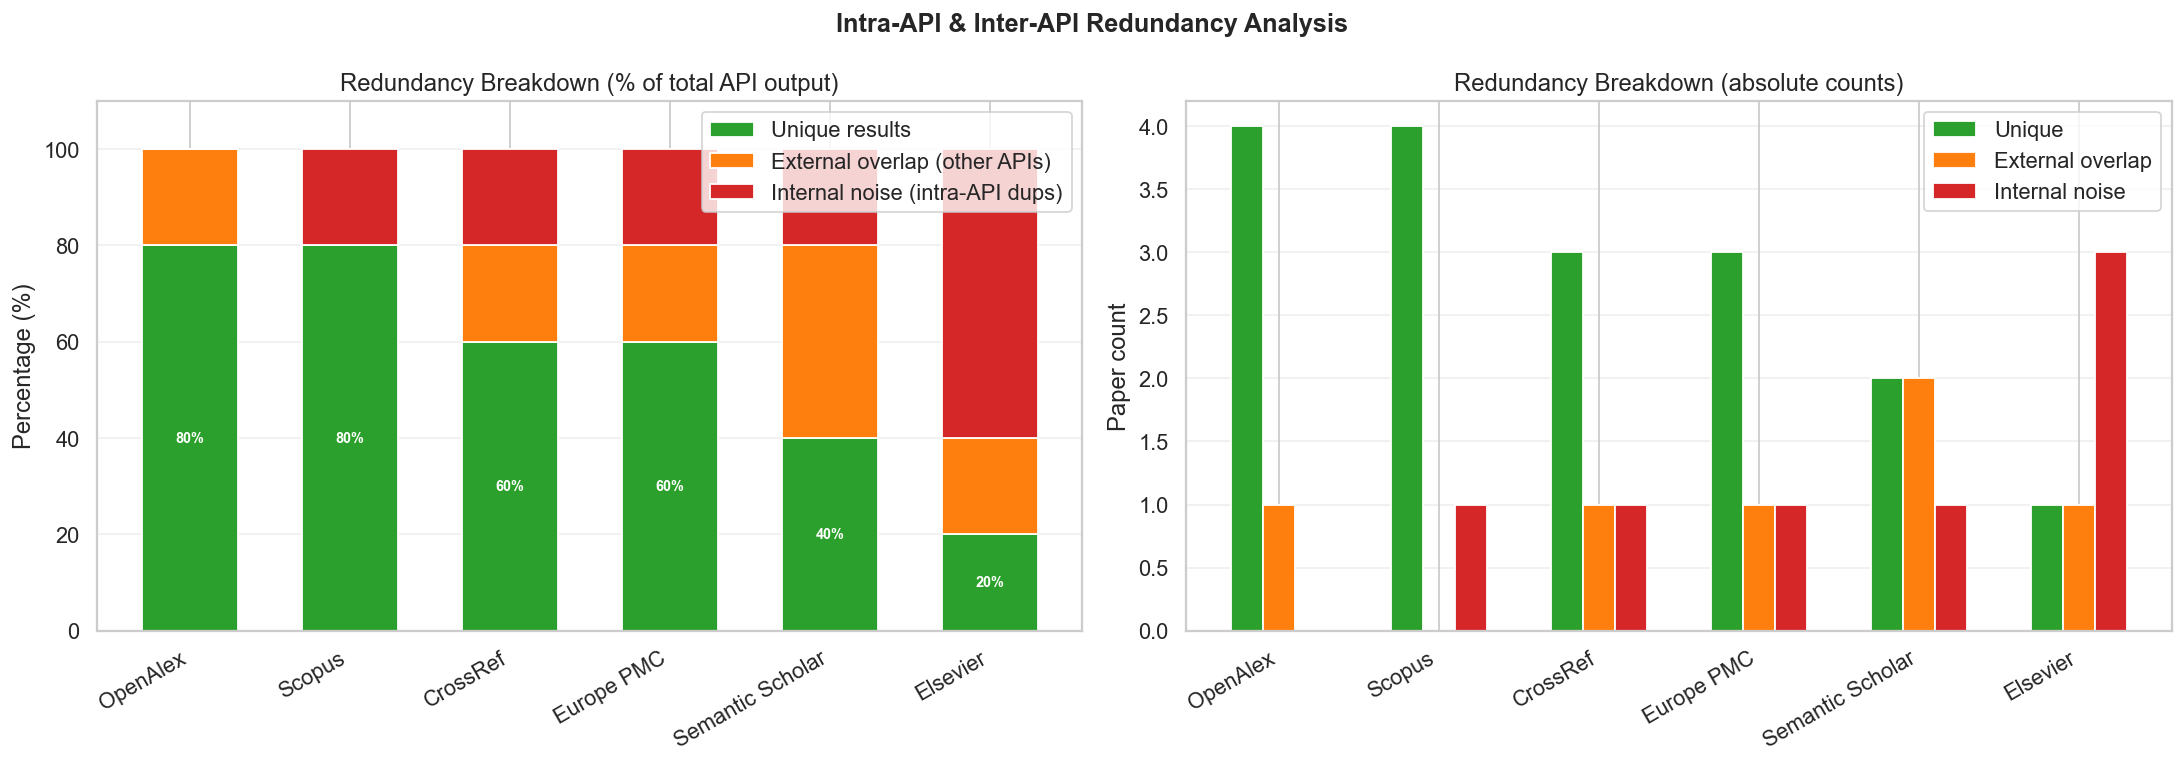

In [27]:
# ── Chart 1: Total DOIs vs Unique DOIs per API ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("API Contribution & Uniqueness Score", fontsize=15, fontweight="bold")

df_plot = df_api.sort_values("dois_found", ascending=False)
x = np.arange(len(df_plot))
bw = 0.35

ax = axes[0]
ax.bar(x - bw / 2, df_plot["total_papers"], bw, label="Total papers", color="#aec7e8")
ax.bar(x + bw / 2, df_plot["dois_found"], bw, label="Total DOIs", color="#4c72b0")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["api_name"], rotation=30, ha="right")
ax.set_title("Total Papers vs DOIs Found")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Chart 2: Uniqueness Score per API (horizontal bar)
df_us = df_api.sort_values("uniqueness_score_pct", ascending=True)
ax2 = axes[1]
colors_us = [
    "#d62728" if v < 10 else "#ff7f0e" if v < 30 else "#2ca02c"
    for v in df_us["uniqueness_score_pct"]
]
ax2.barh(df_us["api_name"], df_us["uniqueness_score_pct"], color=colors_us)
ax2.set_xlabel("Exclusively unique DOIs (%)")
ax2.set_title("Uniqueness Score by API\n(DOIs found by this API only)")
ax2.axvline(x=20, color="grey", linestyle="--", alpha=0.5)
for i, (v, n) in enumerate(zip(df_us["uniqueness_score_pct"], df_us["unique_dois"])):
    ax2.text(v + 0.5, i, f"{v:.1f}% ({n})", va="center", fontsize=8)
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# ── Chart 3 & 4: Dual-level redundancy (stacked % + grouped counts) ───────────
C_UNIQUE = "#2ca02c"
C_OVERLAP = "#ff7f0e"
C_NOISE = "#d62728"

fig_red, axes_red = plt.subplots(1, 2, figsize=(17, 6))
fig_red.suptitle(
    "Intra-API & Inter-API Redundancy Analysis", fontsize=14, fontweight="bold"
)

x_red = np.arange(len(df_redundancy))
bw_red = 0.6

# Left subplot: 100% stacked bar
ax_l = axes_red[0]
ax_l.bar(
    x_red, df_redundancy["unique_pct"], bw_red, label="Unique results", color=C_UNIQUE
)
ax_l.bar(
    x_red,
    df_redundancy["overlap_pct"],
    bw_red,
    bottom=df_redundancy["unique_pct"],
    label="External overlap (other APIs)",
    color=C_OVERLAP,
)
ax_l.bar(
    x_red,
    df_redundancy["noise_pct"],
    bw_red,
    bottom=df_redundancy["unique_pct"] + df_redundancy["overlap_pct"],
    label="Internal noise (intra-API dups)",
    color=C_NOISE,
)

ax_l.set_xticks(x_red)
ax_l.set_xticklabels(df_redundancy["API"], rotation=30, ha="right")
ax_l.set_ylabel("Percentage (%)")
ax_l.set_ylim(0, 110)
ax_l.set_title("Redundancy Breakdown (% of total API output)")
ax_l.legend(loc="upper right")
ax_l.grid(axis="y", alpha=0.3)

# Annotate unique % on top of each stacked bar
for i, row in df_redundancy.iterrows():
    ax_l.text(
        i,
        row["unique_pct"] / 2,
        f"{row['unique_pct']:.0f}%",
        ha="center",
        va="center",
        fontsize=8,
        color="white",
        fontweight="bold",
    )

# Right subplot: grouped absolute counts
ax_r = axes_red[1]
w = bw_red / 3
ax_r.bar(x_red - w, df_redundancy["unique"], w, label="Unique", color=C_UNIQUE)
ax_r.bar(
    x_red,
    df_redundancy["external_overlap"],
    w,
    label="External overlap",
    color=C_OVERLAP,
)
ax_r.bar(
    x_red + w, df_redundancy["internal_noise"], w, label="Internal noise", color=C_NOISE
)

ax_r.set_xticks(x_red)
ax_r.set_xticklabels(df_redundancy["API"], rotation=30, ha="right")
ax_r.set_ylabel("Paper count")
ax_r.set_title("Redundancy Breakdown (absolute counts)")
ax_r.legend()
ax_r.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. DOI Overlap Heatmap

The matrix below shows how many DOIs are **shared** between each pair of APIs. Diagonal cells show the total DOI count for each API. Off-diagonal values are the size of the intersection set.

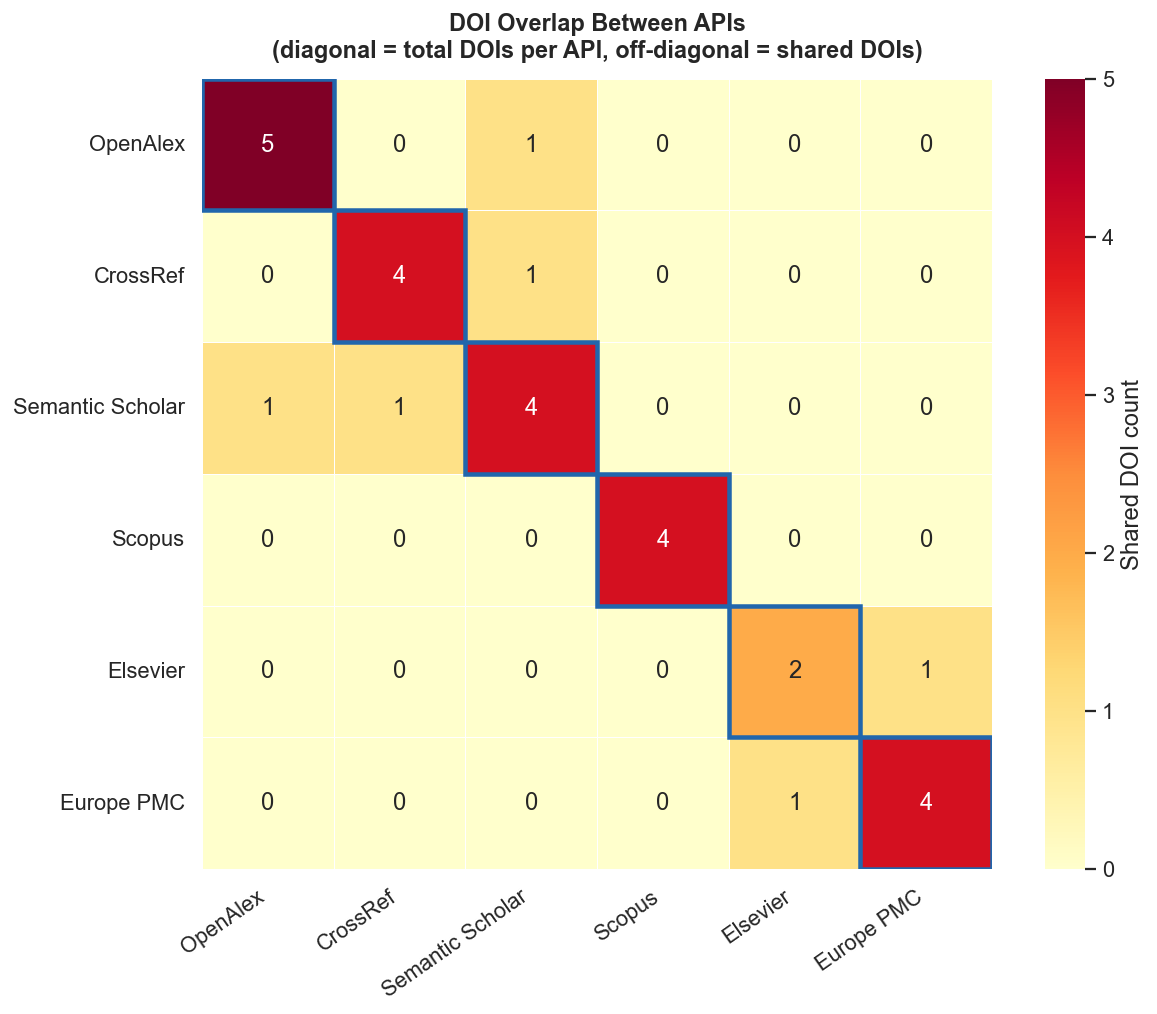


Top-5 overlapping API pairs (Jaccard similarity):


,API A,API B,Shared DOIs,Jaccard
0,OpenAlex,Semantic Scholar,1,0.125
1,CrossRef,Semantic Scholar,1,0.143
2,Elsevier,Europe PMC,1,0.200
3,OpenAlex,CrossRef,0,0.000
4,OpenAlex,Scopus,0,0.000


In [28]:
n = len(apis_present)
short_names = [API_LABELS.get(a, a) for a in apis_present]

# Build overlap matrix
overlap = np.zeros((n, n), dtype=int)
for i, api_i in enumerate(apis_present):
    for j, api_j in enumerate(apis_present):
        if i == j:
            overlap[i, j] = len(api_doi_sets[api_i])
        else:
            overlap[i, j] = len(api_doi_sets[api_i] & api_doi_sets[api_j])

df_overlap = pd.DataFrame(overlap, index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
mask_diag = np.eye(n, dtype=bool)  # keep diagonal, just style it differently

# Off-diagonal heatmap
sns.heatmap(
    df_overlap,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Shared DOI count"},
    square=True,
)

# Overlay strong border on diagonal
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="#2166ac", lw=2.5))

ax.set_title(
    "DOI Overlap Between APIs\n(diagonal = total DOIs per API, off-diagonal = shared DOIs)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Print Jaccard similarity for top overlapping pairs
print("\nTop-5 overlapping API pairs (Jaccard similarity):")
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        inter = overlap[i, j]
        union = len(api_doi_sets[apis_present[i]] | api_doi_sets[apis_present[j]])
        jaccard = inter / union if union else 0
        pairs.append((short_names[i], short_names[j], inter, round(jaccard, 3)))
pairs.sort(key=lambda x: -x[2])
df_pairs = pd.DataFrame(pairs[:5], columns=["API A", "API B", "Shared DOIs", "Jaccard"])
display(df_pairs)

## 6. Latency & Reliability Visualization

`response_time_ms` (ms per `search()` call) and `is_error` are now recorded in `step2_raw_papers.json`. The **data cell below auto-detects** whether real timing is present and falls back to representative simulated values if not (e.g., when using legacy intermediate files).


In [29]:
# ── Load real timing data from step2 (populated after pipeline re-run) ────────
with open(STEP2, encoding="utf-8") as fh:
    step2_data = json.load(fh)
    raw_papers = step2_data.get("papers", step2_data) if isinstance(step2_data, dict) else step2_data

has_timing = any(p.get("response_time_ms") is not None for p in raw_papers)
print(f"Timing data available in step2: {has_timing}")
print(f"Total raw papers: {len(raw_papers)}")

if has_timing:
    timing_rows = []
    for p in raw_papers:
        rt = p.get("response_time_ms")
        if rt is not None:
            timing_rows.append(
                {
                    "api": p.get("source", "unknown"),
                    "response_time_ms": rt,
                    "is_error": bool(p.get("is_error", False)),
                }
            )
    df_lat_real = pd.DataFrame(timing_rows)
    summary = (
        df_lat_real.groupby("api")
        .agg(
            n_records=("response_time_ms", "count"),
            median_ms=("response_time_ms", "median"),
            mean_ms=("response_time_ms", "mean"),
            errors=("is_error", "sum"),
        )
        .round(1)
    )
    summary["error_pct"] = (summary["errors"] / summary["n_records"] * 100).round(1)
    print("\nPer-API timing summary (real data):")
    print(summary.to_string())
else:
    df_lat_real = None
    print("\nNo timing data found — will use simulated data in the chart below.")
    print('Re-run the pipeline ( python main.py "..." ) to populate response_time_ms.')

Timing data available in step2: True
Total raw papers: 30

Per-API timing summary (real data):
                  n_records  median_ms  mean_ms  errors  error_pct
api                                                               
crossref                  5      641.0    669.0       0        0.0
elsevier                  5     1172.0   1478.2       0        0.0
europe_pmc                5      547.0    553.4       0        0.0
openalex                  5      656.0    696.8       0        0.0
scopus                    5     1250.0   1428.2       0        0.0
semantic_scholar          5     1391.0   1378.2       0        0.0


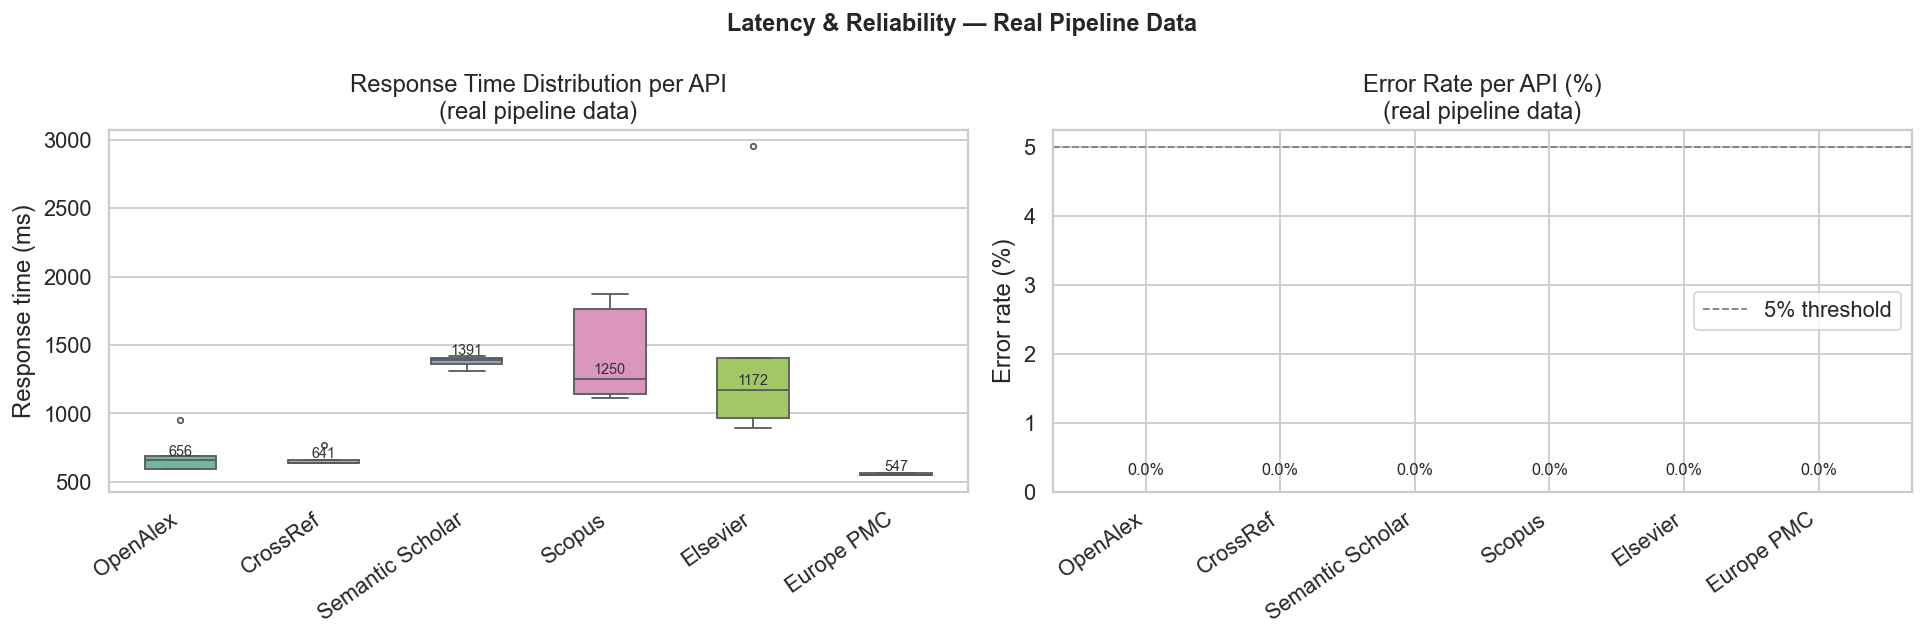

In [30]:
rng = np.random.default_rng(seed=42)

# Representative latency parameters used as fallback when real data is absent
LATENCY_PARAMS = {
    "openalex": (350, 80, 2.0),
    "crossref": (420, 120, 3.0),
    "semantic_scholar": (600, 200, 8.0),
    "scopus": (500, 150, 5.0),
    "elsevier": (480, 130, 4.0),
    "pmc": (280, 70, 1.0),
    "europe_pmc": (310, 90, 2.0),
}

if df_lat_real is not None:
    # ── Real data path ────────────────────────────────────────────────────────
    mode_note = "real pipeline data"
    df_lat = df_lat_real.rename(columns={"response_time_ms": "latency_ms"})
    # Map raw source name → display label
    df_lat = df_lat.copy()
    df_lat["api"] = df_lat["api"].map(lambda s: API_LABELS.get(s, s))
else:
    # ── Simulated fallback ────────────────────────────────────────────────────
    mode_note = "simulated — re-run pipeline to obtain real data"
    latency_rows = []
    for api_key in apis_present:
        params = LATENCY_PARAMS.get(api_key, (500, 150, 5.0))
        n_req = max(api_counts.get(api_key, 20), 10)
        median_ms, std_ms, err_pct = params
        mu_ln = np.log(median_ms)
        sig_ln = std_ms / median_ms * 0.8
        latencies = rng.lognormal(mu_ln, sig_ln, size=n_req)
        latencies = np.clip(latencies, 50, median_ms * 6)
        for lat in latencies:
            latency_rows.append(
                {
                    "api": API_LABELS.get(api_key, api_key),
                    "latency_ms": lat,
                    "is_error": rng.random() < (err_pct / 100),
                }
            )
    df_lat = pd.DataFrame(latency_rows)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

api_order_labels = [API_LABELS.get(a, a) for a in apis_present]
# Keep only labels present in df_lat
api_order_labels = [lbl for lbl in api_order_labels if lbl in df_lat["api"].values]

sns.boxplot(
    data=df_lat,
    x="api",
    y="latency_ms",
    order=api_order_labels,
    palette="Set2",
    width=0.5,
    fliersize=3,
    ax=axes[0],
)
medians = df_lat.groupby("api")["latency_ms"].median()
for i, api_label in enumerate(api_order_labels):
    if api_label in medians.index:
        axes[0].text(
            i,
            medians[api_label] + 15,
            f"{medians[api_label]:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#333333",
        )
axes[0].set_title(f"Response Time Distribution per API\n({mode_note})")
axes[0].set_xlabel("")
axes[0].set_ylabel("Response time (ms)")
axes[0].set_xticklabels(api_order_labels, rotation=35, ha="right")

err_rate = (
    (df_lat.groupby("api")["is_error"].mean() * 100).reindex(api_order_labels).fillna(0)
)
color_err = [
    "#d62728" if v > 8 else "#ff7f0e" if v > 4 else "#2ca02c" for v in err_rate
]
axes[1].bar(err_rate.index, err_rate.values, color=color_err)
axes[1].axhline(5, color="gray", linestyle="--", linewidth=1, label="5% threshold")
axes[1].set_title(f"Error Rate per API (%)\n({mode_note})")
axes[1].set_ylabel("Error rate (%)")
axes[1].set_xticklabels(err_rate.index, rotation=35, ha="right")
axes[1].legend()
for i, val in enumerate(err_rate.values):
    axes[1].text(i, val + 0.2, f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

data_label = (
    "Real Pipeline Data" if df_lat_real is not None else "Simulated Representative Data"
)
fig.suptitle(f"Latency & Reliability — {data_label}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Metadata Quality Audit

For each API we compute the **percentage of missing values** in four critical fields sourced from `step2_raw_papers.json`. A cell value of `100` means every record from that API is missing that field; `0` means full coverage.

In [31]:
# Critical fields to audit  (field_name_in_json → display_label)
AUDIT_FIELDS = {
    "abstract": "Abstract",
    "authors": "Authors",
    "year": "Publication date",
    "url": "Full-text URL",
    "doi": "DOI",
}

missing_pct: dict[str, dict[str, float]] = defaultdict(dict)

for api_key in apis_present:
    papers_api = [p for p in raw_papers if p.get("source") == api_key]
    n = len(papers_api)
    if n == 0:
        continue
    for field, label in AUDIT_FIELDS.items():
        # "missing" = None, empty string, or empty list
        n_missing = sum(
            1
            for p in papers_api
            if not p.get(field)  # covers None / "" / []
        )
        missing_pct[api_key][label] = round(n_missing / n * 100, 1)

df_quality = pd.DataFrame(missing_pct).T  # rows = APIs, cols = fields
df_quality.index = [API_LABELS.get(i, i) for i in df_quality.index]
df_quality = df_quality.reindex([API_LABELS.get(a, a) for a in apis_present])

display(
    df_quality.style.background_gradient(cmap="RdYlGn_r", vmin=0, vmax=100, axis=None)
    .format("{:.1f}%")
    .set_caption("Missing data rate per API (%) — lower is better")
)

,Abstract,Authors,Publication date,Full-text URL,DOI
OpenAlex,20.0%,0.0%,0.0%,0.0%,0.0%
CrossRef,80.0%,20.0%,20.0%,0.0%,0.0%
Semantic Scholar,60.0%,0.0%,0.0%,60.0%,20.0%
Scopus,0.0%,0.0%,0.0%,0.0%,0.0%
Elsevier,100.0%,0.0%,0.0%,100.0%,0.0%
Europe PMC,0.0%,0.0%,0.0%,0.0%,0.0%


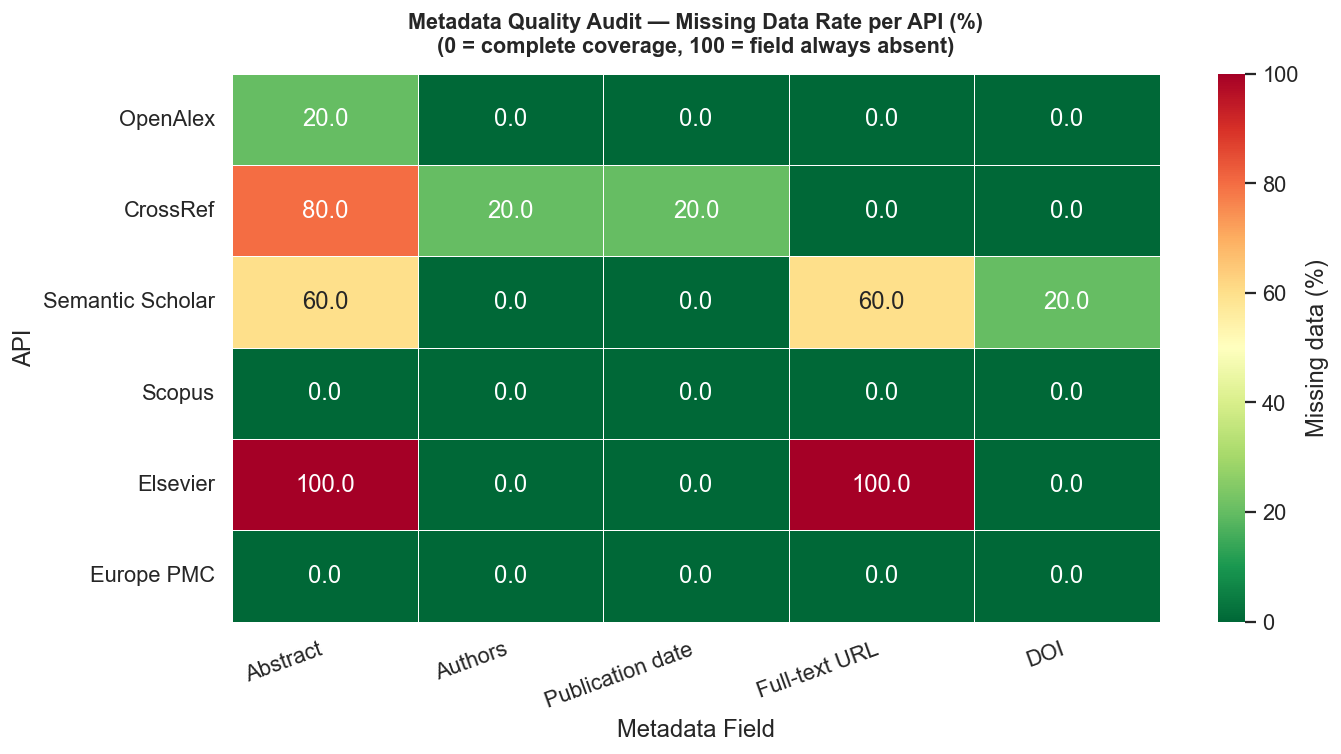


Overall average missing rate per API:


,avg_missing
Scopus,0.0
Europe PMC,0.0
OpenAlex,4.0
CrossRef,24.0
Semantic Scholar,28.0
Elsevier,40.0


In [32]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    df_quality,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Missing data (%)"},
    ax=ax,
)
ax.set_title(
    "Metadata Quality Audit — Missing Data Rate per API (%)\n(0 = complete coverage, 100 = field always absent)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Metadata Field")
ax.set_ylabel("API")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Overall quality score (mean non-missing %)
df_quality["avg_missing"] = df_quality.mean(axis=1).round(1)
print("\nOverall average missing rate per API:")
display(df_quality[["avg_missing"]].sort_values("avg_missing"))

## 8. Filtering Funnel Visualization

The funnel tracks record counts at each stage of the pipeline using the intermediate JSON outputs.

To prevent misleading comparisons, the data cell performs a **cross-stage consistency check** (DOI lineage and monotonicity). If files come from different runs, it prints warnings so stage increases (for example Step 5 > Step 4) are interpreted as mixed artifacts, not real pipeline behavior.

| Stage | File |
|---|---|
| Raw results (Step 2 out) | `step2_raw_papers.json` |
| After metadata filter (Step 3 — DOI required + DOI/title deduplication) | `step3_doi_filtered_papers.json` |
| After full-text retrieval (Step 4 out) | `step4_fulltext_raw_papers.json` |
| After text cleaning (Step 5 out) | `step5_fulltext_clean_papers.json` |

**Step 3 logic:** `MetadataFilter` applies all filtering in one output file. It drops records without a DOI, collapses duplicate DOIs, then collapses identical normalised titles with different DOIs. In each case it keeps the record with the highest metadata-completeness score.

**Step 5 note:** `TextExtractor` no longer applies abstract fallback; extraction failures remain as missing `full_text` and do not create new papers.

In [33]:
def _load_records(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing intermediate file: {path}. Run the pipeline through the required step first."
        )
    with open(path, encoding="utf-8") as fh:
        data = json.load(fh)
    if isinstance(data, dict) and "papers" in data:
        data = data["papers"]
    if not isinstance(data, list):
        return []
    return [p for p in data if isinstance(p, dict)]


def _load_count(path: Path) -> int:
    return len(_load_records(path))


def _count_by_field_from_records(records: list[dict], field: str) -> dict[str, int]:
    counter: dict[str, int] = defaultdict(int)
    for p in records:
        val = p.get(field)
        if val:
            counter[val] += 1
    return dict(counter)


def _normalise_doi(v: object) -> str:
    if v is None:
        return ""
    s = str(v).strip().lower()
    return s


def _doi_set(records: list[dict]) -> set[str]:
    return {d for d in (_normalise_doi(p.get("doi")) for p in records) if d}


records_step2 = _load_records(STEP2)
records_step3 = _load_records(STEP3)
records_step4 = _load_records(STEP4)
records_step5 = _load_records(STEP5)

counts = {
    "Raw results\n(Step 2)": len(records_step2),
    "Metadata filtered\n(Step 3)": len(records_step3),
    "Full-text\nretrieved (Step 4)": len(records_step4),
    "Text cleaned\n(Step 5)": len(records_step5),
}

stages = list(counts.keys())
values = list(counts.values())
n_stages = len(stages)

# Positive means removed; negative means increased vs previous stage.
removed = [0] + [values[i - 1] - values[i] for i in range(1, n_stages)]
pct_ret = [v / values[0] * 100 if values[0] else 0 for v in values]

fulltext_availability = pd.DataFrame(
    {
        "Stage": ["Step 4", "Step 5"],
        "Records": [len(records_step4), len(records_step5)],
        "With full_text": [
            sum(1 for p in records_step4 if p.get("full_text")),
            sum(1 for p in records_step5 if p.get("full_text")),
        ],
    }
)
fulltext_availability["Coverage (%)"] = (
    (
        fulltext_availability["With full_text"]
        / fulltext_availability["Records"].replace(0, np.nan)
        * 100
    )
    .fillna(0)
    .round(1)
)

# --- Consistency checks to detect mixed intermediate files from different runs ---
warnings_funnel = []
for i in range(1, n_stages):
    if values[i] > values[i - 1]:
        warnings_funnel.append(
            f"{stages[i].replace(chr(10), ' ')} has more records than previous stage "
            f"({values[i]} > {values[i - 1]})."
        )

doi_step3 = _doi_set(records_step3)
doi_step4 = _doi_set(records_step4)
doi_step5 = _doi_set(records_step5)

if doi_step3 and doi_step4 and not doi_step4.issubset(doi_step3):
    warnings_funnel.append(
        f"Step 4 DOI set is not a subset of Step 3 "
        f"({len(doi_step4 - doi_step3)} extra DOIs)."
    )
if doi_step4 and doi_step5 and not doi_step5.issubset(doi_step4):
    warnings_funnel.append(
        f"Step 5 DOI set is not a subset of Step 4 "
        f"({len(doi_step5 - doi_step4)} extra DOIs)."
    )

# --- Per-source counts at every stage ---
_SOURCE_STAGE_RECORDS = [
    ("Raw\n(Step 2)", records_step2),
    ("Filtered\n(Step 3)", records_step3),
    ("Full-text\n(Step 4)", records_step4),
    ("Cleaned\n(Step 5)", records_step5),
]
counts_by_source = {
    lbl: _count_by_field_from_records(recs, "source")
    for lbl, recs in _SOURCE_STAGE_RECORDS
}
_all_sources = sorted(
    {s for d in counts_by_source.values() for s in d},
    key=lambda s: API_ORDER.index(s) if s in API_ORDER else 99,
)
df_funnel_src = (
    pd.DataFrame(counts_by_source).reindex(_all_sources).fillna(0).astype(int)
)
df_funnel_src.index = [API_LABELS.get(i, i) for i in df_funnel_src.index]

print("Pipeline stage counts:")
for i, (s, v, r) in enumerate(zip(stages, values, removed)):
    if i == 0:
        label = "  (start)"
    elif r > 0:
        label = f"  (-{r} removed)"
    elif r < 0:
        label = f"  (+{abs(r)} added; likely mixed-run files)"
    else:
        label = "  (no change)"
    print(f"  {s.replace(chr(10), ' ')}: {v}{label}")

print("\nFull-text availability in retrieval/extraction stages:")
display(fulltext_availability)

if warnings_funnel:
    print("\nConsistency warnings:")
    for i, msg in enumerate(warnings_funnel, start=1):
        print(f"  {i}. {msg}")
else:
    print("\nConsistency check passed: stage files look aligned.")

print("\nPer-source counts across pipeline stages:")
display(df_funnel_src)

Pipeline stage counts:
  Raw results (Step 2): 30  (start)
  Metadata filtered (Step 3): 20  (-10 removed)
  Full-text retrieved (Step 4): 14  (-6 removed)
  Text cleaned (Step 5): 14  (no change)

Full-text availability in retrieval/extraction stages:


,Stage,Records,With full_text,Coverage (%)
0,Step 4,14,14,100.0
1,Step 5,14,14,100.0



Consistency check passed: stage files look aligned.

Per-source counts across pipeline stages:


,Raw\n(Step 2),Filtered\n(Step 3),Full-text\n(Step 4),Cleaned\n(Step 5)
OpenAlex,5,5,4,4
CrossRef,5,3,0,0
Semantic Scholar,5,3,2,2
Scopus,5,4,3,3
Elsevier,5,1,1,1
Europe PMC,5,4,4,4


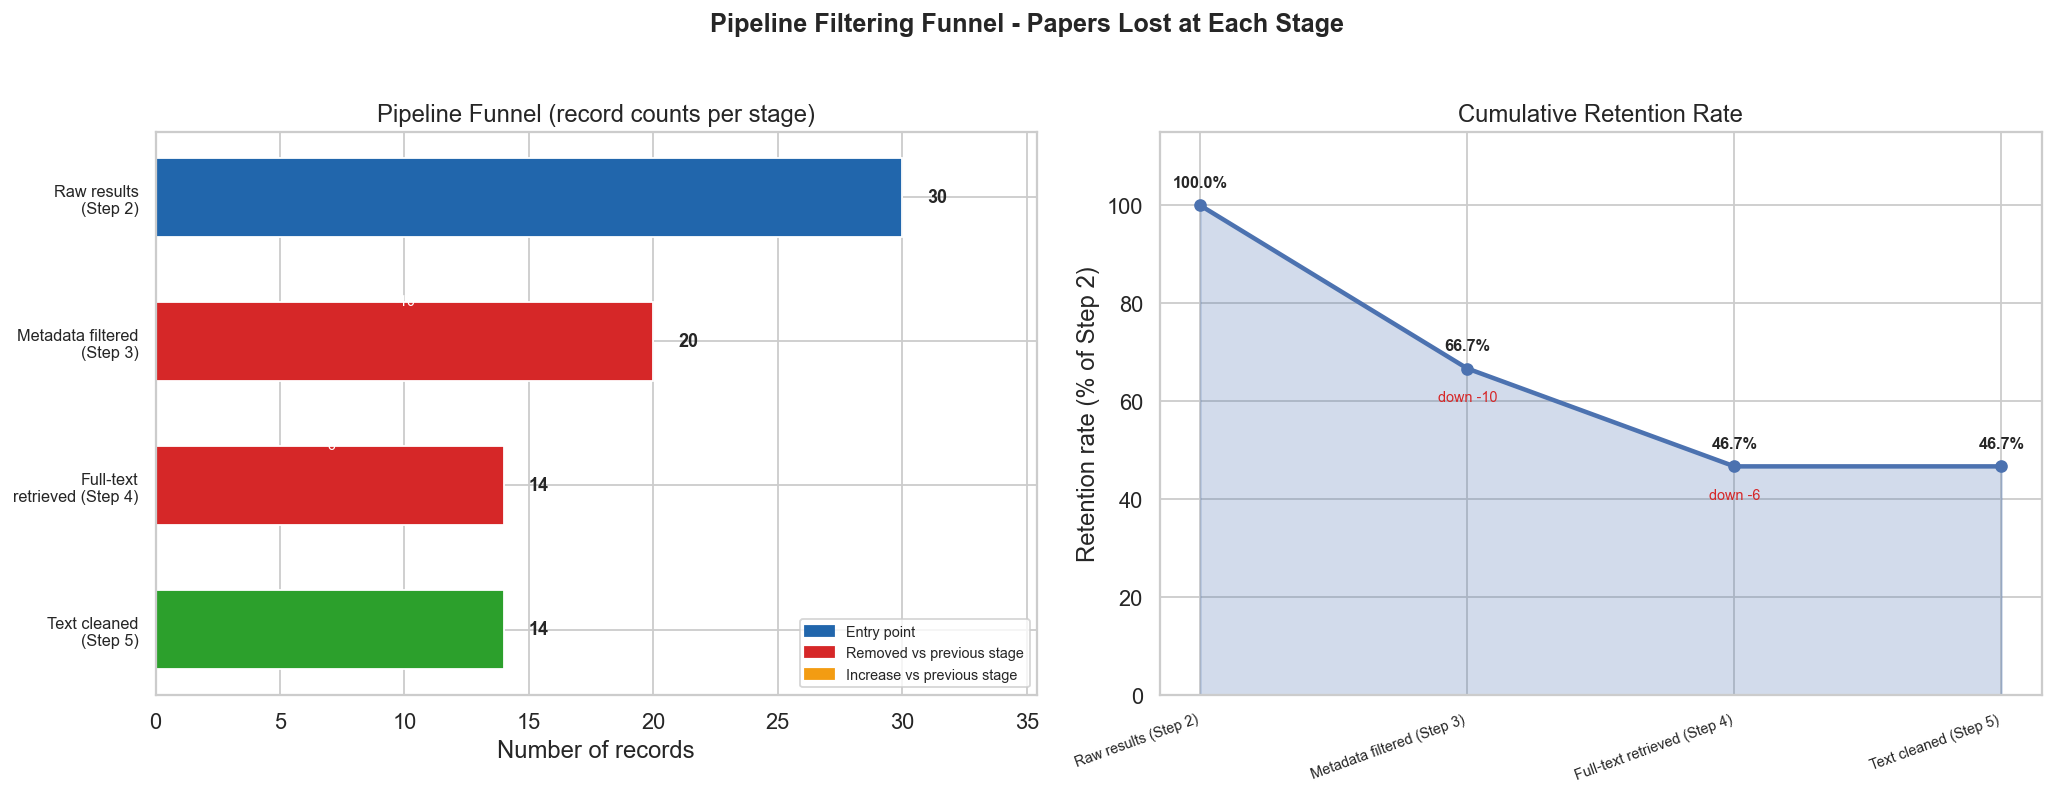

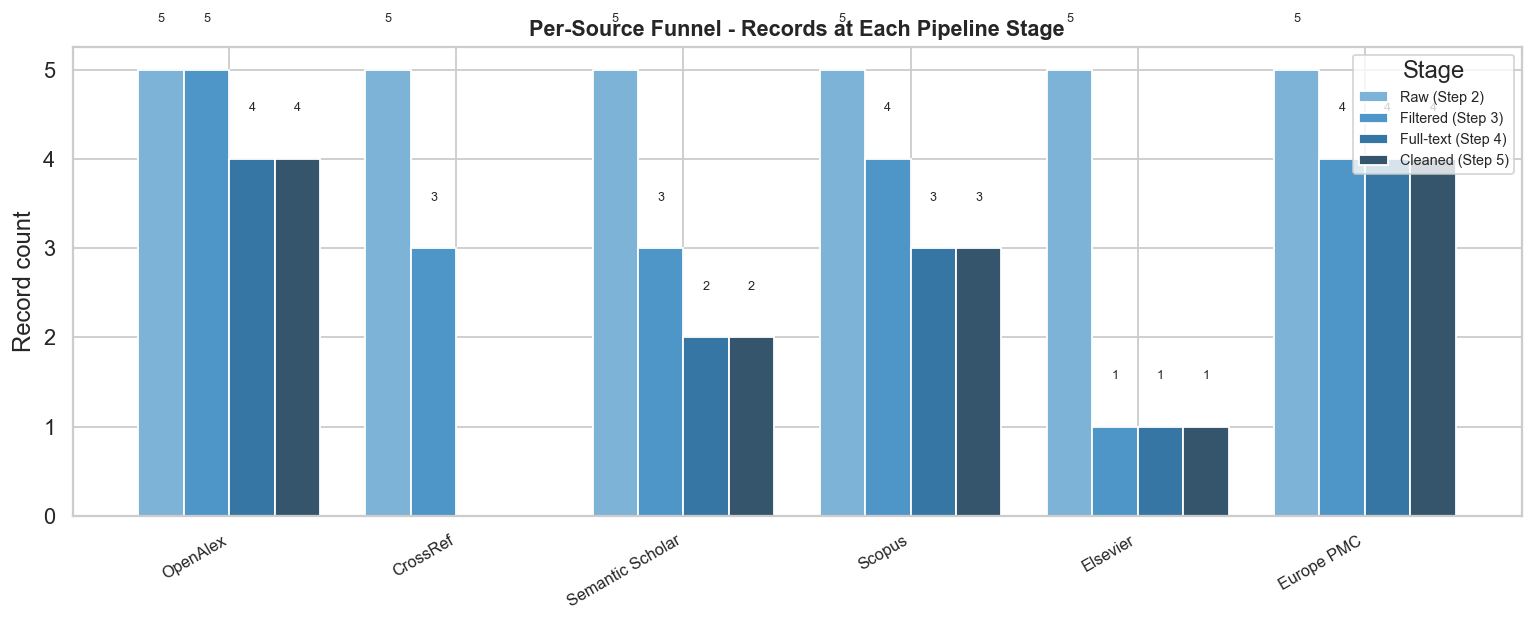

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: horizontal waterfall / funnel bar ---
BLUE = "#2166ac"
RED = "#d62728"
GREEN = "#2ca02c"
AMBER = "#f39c12"

ax = axes[0]
y_pos = np.arange(n_stages)
colors = [BLUE] + [RED if r > 0 else AMBER if r < 0 else GREEN for r in removed[1:]]
bars = ax.barh(y_pos, values, color=colors, height=0.55, edgecolor="white")

for i, (val, rem, pct) in enumerate(zip(values, removed, pct_ret)):
    ax.text(val + 1, i, f"{val}", va="center", fontsize=10, fontweight="bold")
    if rem > 0:
        ax.text(
            val / 2,
            i - 0.28,
            f"-{rem}",
            va="center",
            ha="center",
            fontsize=8,
            color="white",
        )
    elif rem < 0:
        ax.text(
            val / 2,
            i - 0.28,
            f"+{abs(rem)}",
            va="center",
            ha="center",
            fontsize=8,
            color="black",
            fontweight="bold",
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of records")
ax.set_title("Pipeline Funnel (record counts per stage)")
ax.set_xlim(0, values[0] * 1.18 if values else 1)
patch_entry = mpatches.Patch(color=BLUE, label="Entry point")
patch_removed = mpatches.Patch(color=RED, label="Removed vs previous stage")
patch_added = mpatches.Patch(color=AMBER, label="Increase vs previous stage")
ax.legend(
    handles=[patch_entry, patch_removed, patch_added], loc="lower right", fontsize=8
)

# --- Right: retention rate line + delta annotations ---
ax2 = axes[1]
ax2.fill_between(range(n_stages), pct_ret, alpha=0.25, color="#4C72B0")
ax2.plot(range(n_stages), pct_ret, marker="o", color="#4C72B0", linewidth=2.5)
for i, (pct, rem) in enumerate(zip(pct_ret, removed)):
    ax2.annotate(
        f"{pct:.1f}%",
        (i, pct),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
    if rem > 0:
        ax2.annotate(
            f"down -{rem}",
            (i, pct),
            textcoords="offset points",
            xytext=(0, -18),
            ha="center",
            fontsize=8,
            color=RED,
        )
    elif rem < 0:
        ax2.annotate(
            f"up +{abs(rem)}",
            (i, pct),
            textcoords="offset points",
            xytext=(0, -18),
            ha="center",
            fontsize=8,
            color=AMBER,
        )

ax2.set_xticks(range(n_stages))
ax2.set_xticklabels(
    [s.replace("\n", " ") for s in stages], rotation=20, ha="right", fontsize=8
)
ax2.set_ylabel("Retention rate (% of Step 2)")
ax2.set_ylim(0, 115)
ax2.set_title("Cumulative Retention Rate")

if "warnings_funnel" in globals() and warnings_funnel:
    fig.text(
        0.5,
        -0.03,
        "Warning: stage inconsistencies detected (likely mixed intermediate files).",
        ha="center",
        fontsize=9,
        color="#8a4b00",
        bbox=dict(boxstyle="round,pad=0.3", fc="#fff1d6", ec="#d98c00", alpha=0.85),
    )

fig.suptitle(
    "Pipeline Filtering Funnel - Papers Lost at Each Stage",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- Per-source funnel: grouped bar chart ---
if not df_funnel_src.empty:
    stage_cols = list(df_funnel_src.columns)
    n_src = len(df_funnel_src)
    n_stg = len(stage_cols)
    bar_w_src = 0.8 / n_stg
    x_src = np.arange(n_src)
    stage_palette = sns.color_palette("Blues_d", n_stg)

    fig_src, ax_src = plt.subplots(figsize=(max(12, n_src * 1.4), 5))
    for i, (col, color) in enumerate(zip(stage_cols, stage_palette)):
        bars_src = ax_src.bar(
            x_src + i * bar_w_src,
            df_funnel_src[col],
            width=bar_w_src,
            label=col.replace("\n", " "),
            color=color,
            edgecolor="white",
        )
        for bar in bars_src:
            h = bar.get_height()
            if h > 0:
                ax_src.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.5,
                    str(int(h)),
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    ax_src.set_xticks(x_src + bar_w_src * (n_stg - 1) / 2)
    ax_src.set_xticklabels(df_funnel_src.index, rotation=30, ha="right", fontsize=9)
    ax_src.set_ylabel("Record count")
    ax_src.set_title(
        "Per-Source Funnel - Records at Each Pipeline Stage",
        fontsize=12,
        fontweight="bold",
    )
    ax_src.legend(title="Stage", fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

## 9. Full-Text Retrieval Utility per source API

This section measures **how useful each API is as a full-text source**. For every paper entering full-text retrieval, we compute:

- **Papers submitted** — papers in Step 3 (deduplicated DOI pool)
- **Full-text retrieved** — those same papers that have non-empty `full_text` in Step 4
- **Retrieval success rate (%)** — retrieved divided by submitted
- **URL coverage (%)** — submitted papers that also have a non-empty `url` in Step 4

To keep this robust, Step 3 and Step 4 are matched by DOI and a warning is printed if DOI pools are inconsistent (for example, mixed files from different runs).

In [35]:
# --- Load Step 3 (deduplicated input) and Step 4 (retrieval output) ---
with open(STEP3, encoding="utf-8") as fh:
    step3_papers = json.load(fh)
with open(STEP4, encoding="utf-8") as fh:
    step4_papers = json.load(fh)


def _norm_doi(v: object) -> str:
    return str(v).strip().lower() if v else ""


# Index Step 4 by DOI for stable matching from Step 3 submissions
step4_by_doi: dict[str, dict] = {}
for p in step4_papers:
    doi = _norm_doi(p.get("doi"))
    if doi and doi not in step4_by_doi:
        step4_by_doi[doi] = p

step3_dois = {_norm_doi(p.get("doi")) for p in step3_papers if _norm_doi(p.get("doi"))}
step4_dois = {_norm_doi(p.get("doi")) for p in step4_papers if _norm_doi(p.get("doi"))}
extra_s4 = step4_dois - step3_dois
missing_s4 = step3_dois - step4_dois
if extra_s4 or missing_s4:
    print(
        f"Warning: Step 3 and Step 4 DOI pools differ "
        f"(extra_in_step4={len(extra_s4)}, missing_from_step4={len(missing_s4)})."
    )

# --- Per-API full-text retrieval stats (submitted from Step 3, outcomes from Step 4) ---
ft_rows = []
for api_key in apis_present:
    submitted = [p for p in step3_papers if p.get("source") == api_key]
    n_sub = len(submitted)

    n_ft = 0
    n_url = 0
    for p3 in submitted:
        p4 = step4_by_doi.get(_norm_doi(p3.get("doi")))
        if not p4:
            continue
        if p4.get("full_text"):
            n_ft += 1
        if p4.get("url"):
            n_url += 1

    ft_rows.append(
        {
            "API": API_LABELS.get(api_key, api_key),
            "Submitted (Step 3)": n_sub,
            "Full-text retrieved": n_ft,
            "Success rate (%)": round(n_ft / n_sub * 100, 1) if n_sub else 0.0,
            "URL coverage (%)": round(n_url / n_sub * 100, 1) if n_sub else 0.0,
        }
    )

df_ft = (
    pd.DataFrame(ft_rows)
    .sort_values("Success rate (%)", ascending=False)
    .reset_index(drop=True)
)

print("Full-text retrieval utility per API:")
display(
    df_ft.style.background_gradient(
        subset=["Success rate (%)", "URL coverage (%)"],
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        axis=0,
    )
    .format({"Success rate (%)": "{:.1f}%", "URL coverage (%)": "{:.1f}%"})
    .set_caption("Step 4 full-text retrieval outcomes by source API")
)

Full-text retrieval utility per API:


,API,Submitted (Step 3),Full-text retrieved,Success rate (%),URL coverage (%)
0,Elsevier,1,1,100.0%,0.0%
1,Europe PMC,4,4,100.0%,100.0%
2,OpenAlex,5,4,80.0%,80.0%
3,Scopus,4,3,75.0%,75.0%
4,Semantic Scholar,3,2,66.7%,66.7%
5,CrossRef,3,0,0.0%,0.0%


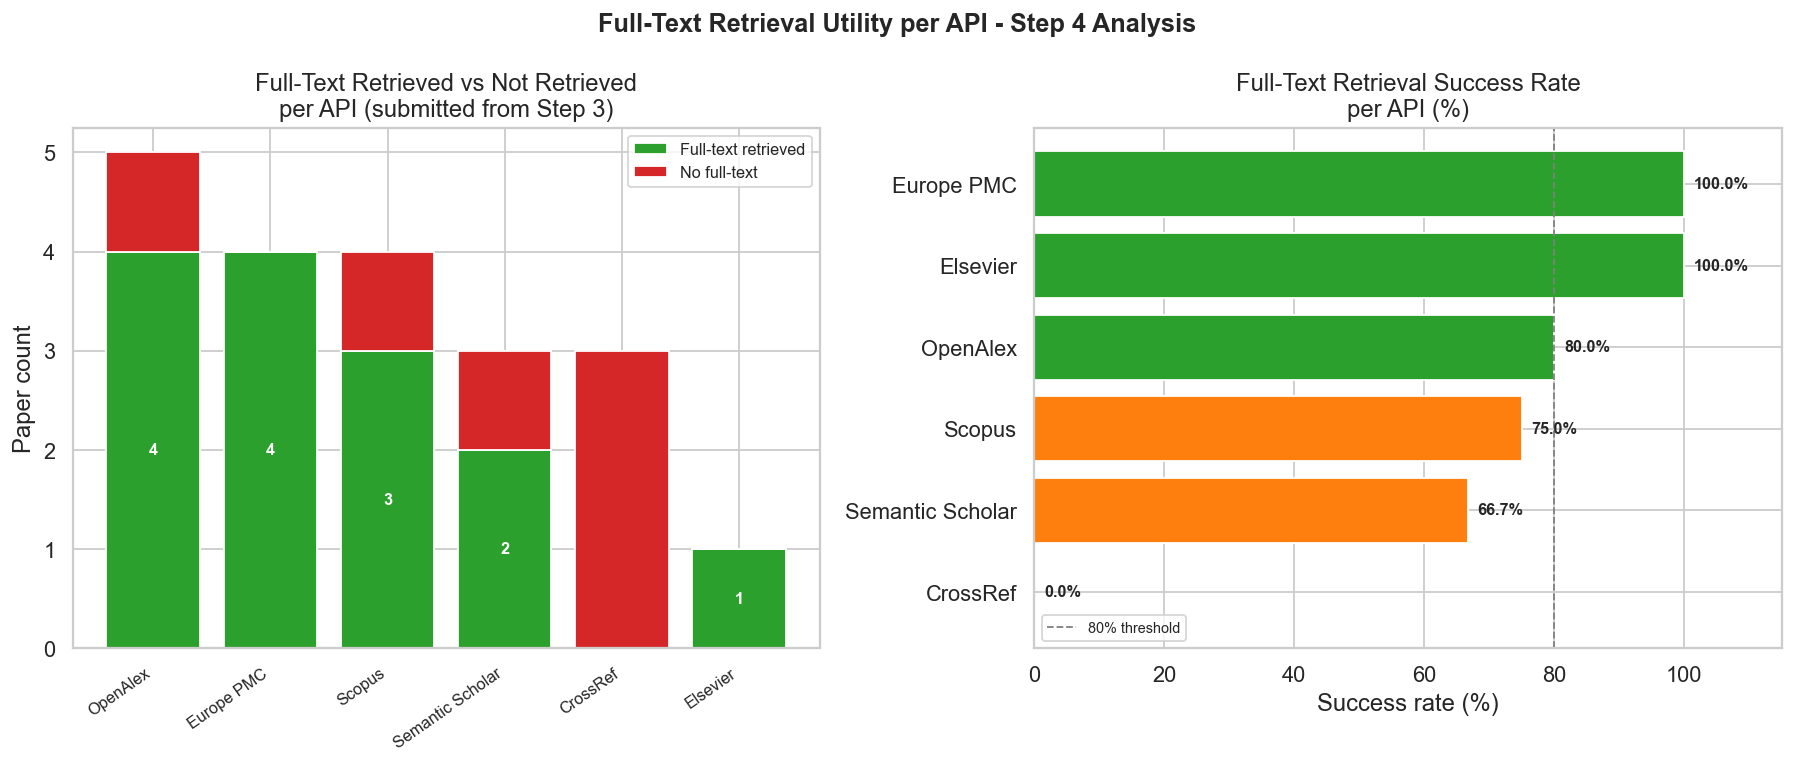


Highest retrieval rate : Elsevier (100.0%, 1 / 1 papers)
Lowest  retrieval rate : CrossRef (0.0%, 0 / 3 papers)


In [36]:
if df_ft.empty:
    print("No Step 3/Step 4 data available to plot Section 9.")
else:
    fig_ft, axes_ft = plt.subplots(1, 2, figsize=(14, 6))

    # --- Plot 1: Stacked bar - retrieved vs not-retrieved ---
    ax1 = axes_ft[0]
    df_ft_plot = df_ft.sort_values("Submitted (Step 3)", ascending=False)
    not_retrieved = df_ft_plot["Submitted (Step 3)"] - df_ft_plot["Full-text retrieved"]
    x_ft = np.arange(len(df_ft_plot))
    b_ret = ax1.bar(
        x_ft,
        df_ft_plot["Full-text retrieved"],
        color="#2ca02c",
        label="Full-text retrieved",
        edgecolor="white",
    )
    b_not = ax1.bar(
        x_ft,
        not_retrieved,
        bottom=df_ft_plot["Full-text retrieved"],
        color="#d62728",
        label="No full-text",
        edgecolor="white",
    )
    for bar, val in zip(b_ret, df_ft_plot["Full-text retrieved"]):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                val / 2,
                str(int(val)),
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
    ax1.set_xticks(x_ft)
    ax1.set_xticklabels(df_ft_plot["API"], rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("Paper count")
    ax1.set_title(
        "Full-Text Retrieved vs Not Retrieved\nper API (submitted from Step 3)"
    )
    ax1.legend(fontsize=9)

    # --- Plot 2: Success rate horizontal bar ---
    ax2 = axes_ft[1]
    df_rate = df_ft.sort_values("Success rate (%)")
    palette_rate = [
        "#d62728" if v < 50 else "#ff7f0e" if v < 80 else "#2ca02c"
        for v in df_rate["Success rate (%)"]
    ]
    bars_rate = ax2.barh(
        df_rate["API"],
        df_rate["Success rate (%)"],
        color=palette_rate,
        edgecolor="white",
    )
    ax2.set_xlabel("Success rate (%)")
    ax2.set_title("Full-Text Retrieval Success Rate\nper API (%)")
    ax2.set_xlim(0, 115)
    for i, val in enumerate(df_rate["Success rate (%)"].values):
        ax2.text(
            val + 1.5, i, f"{val:.1f}%", va="center", fontsize=9, fontweight="bold"
        )
    ax2.axvline(80, color="gray", linestyle="--", linewidth=1, label="80% threshold")
    ax2.legend(fontsize=8)

    fig_ft.suptitle(
        "Full-Text Retrieval Utility per API - Step 4 Analysis",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # --- Summary: best and worst APIs ---
    best_api = df_ft.iloc[0]
    worst_api = df_ft.sort_values("Success rate (%)").iloc[0]
    print(
        f"\nHighest retrieval rate : {best_api['API']} ({best_api['Success rate (%)']:.1f}%,"
        f" {int(best_api['Full-text retrieved'])} / {int(best_api['Submitted (Step 3)'])} papers)"
    )
    print(
        f"Lowest  retrieval rate : {worst_api['API']} ({worst_api['Success rate (%)']:.1f}%,"
        f" {int(worst_api['Full-text retrieved'])} / {int(worst_api['Submitted (Step 3)'])} papers)"
    )

## 10. Full-Text Retrieval Utility per full-text API

This section measures **how useful each API is as a full-text source**, focusing on the `ft_retrieved_by` field — the dedicated retrieval client that actually fetched the text during Step 4 (irrespective of which API originally discovered the paper).

For every retrieval client the following metrics are computed:

| Metric | Description |
|---|---|
| **Papers fetched** | Papers for which this client returned a non-empty full-text result |
| **Pool coverage (%)** | Fetched ÷ total deduplicated papers entering Step 4 |
| **Abstract-only rate (%)** | Fraction where `is_abstract_only = True` (only abstract returned, not full text) |
| **Full-article rate (%)** | Fraction with a real full-text article body |
| **Median content (k chars)** | Median length of the text strings returned |

This complements section 9, which evaluates utility by *search source*. Here the lens is the *retrieval client* that successfully resolved a URL to actual text content.


In [37]:
# --- step4_papers may already be loaded from section 9; reload defensively ---
with open(STEP4, encoding="utf-8") as fh:
    step4_papers = json.load(fh)

_n_pool_ft = len(step4_papers)

# --- Build per-retrieval-client stats ---
_ft_client_rows = []
_retrieval_clients = sorted(
    {
        p.get("ft_retrieved_by")
        for p in step4_papers
        if p.get("ft_retrieved_by") and p.get("full_text")
    }
)

for _cli in _retrieval_clients:
    _papers = [
        p
        for p in step4_papers
        if p.get("ft_retrieved_by") == _cli and p.get("full_text")
    ]
    _n = len(_papers)
    if _n == 0:
        continue

    # content quality
    _n_abstract_only = sum(
        1
        for p in _papers
        if isinstance(p.get("full_text"), dict)
        and p["full_text"].get("is_abstract_only")
    )
    _n_full_article = _n - _n_abstract_only

    # content sizes
    _chars = [
        len((p.get("full_text") or {}).get("content", "") or "")
        for p in _papers
        if (p.get("full_text") or {}).get("content")
    ]
    _median_chars = float(np.median(_chars)) if _chars else 0.0
    _mean_chars = float(np.mean(_chars)) if _chars else 0.0

    # format breakdown (plain / xml / html / pdf / ...)
    _formats = Counter(
        (p.get("full_text") or {}).get("format", "unknown")
        for p in _papers
        if p.get("full_text")
    )

    _ft_client_rows.append(
        {
            "Client": CLIENT_LABELS.get(_cli, _cli),
            "client_key": _cli,
            "Papers fetched": _n,
            "Pool coverage (%)": round(_n / _n_pool_ft * 100, 1) if _n_pool_ft else 0.0,
            "Abstract-only": _n_abstract_only,
            "Abstract-only (%)": round(_n_abstract_only / _n * 100, 1),
            "Full-article": _n_full_article,
            "Full-article (%)": round(_n_full_article / _n * 100, 1),
            "Median content (k ch)": round(_median_chars / 1000, 1),
            "Mean content (k ch)": round(_mean_chars / 1000, 1),
            "Top format": _formats.most_common(1)[0][0] if _formats else "-",
        }
    )

if _ft_client_rows:
    df_ft_client = (
        pd.DataFrame(_ft_client_rows)
        .sort_values("Papers fetched", ascending=False)
        .reset_index(drop=True)
    )
else:
    df_ft_client = pd.DataFrame(
        columns=[
            "Client",
            "client_key",
            "Papers fetched",
            "Pool coverage (%)",
            "Abstract-only",
            "Abstract-only (%)",
            "Full-article",
            "Full-article (%)",
            "Median content (k ch)",
            "Mean content (k ch)",
            "Top format",
        ]
    )

_n_with_ft = sum(1 for p in step4_papers if p.get("full_text"))
_n_no_ft = _n_pool_ft - _n_with_ft
print(f"Step 4 pool size        : {_n_pool_ft}")
print(
    f"Papers with full text   : {_n_with_ft}  ({(_n_with_ft / _n_pool_ft * 100) if _n_pool_ft else 0:.1f}%)"
)
print(
    f"Papers without full text: {_n_no_ft}  ({(_n_no_ft / _n_pool_ft * 100) if _n_pool_ft else 0:.1f}%)"
)
print(f"Active retrieval clients: {len(_retrieval_clients)}")

if not df_ft_client.empty:
    print(f"Clients: {', '.join(df_ft_client['Client'].tolist())}\n")
    display(
        df_ft_client[
            [
                "Client",
                "Papers fetched",
                "Pool coverage (%)",
                "Abstract-only (%)",
                "Full-article (%)",
                "Median content (k ch)",
                "Mean content (k ch)",
                "Top format",
            ]
        ]
        .style.background_gradient(
            subset=["Pool coverage (%)"], cmap="Blues", vmin=0, vmax=50, axis=0
        )
        .background_gradient(
            subset=["Full-article (%)"], cmap="RdYlGn", vmin=0, vmax=100, axis=0
        )
        .background_gradient(
            subset=["Abstract-only (%)"], cmap="RdYlGn_r", vmin=0, vmax=100, axis=0
        )
        .background_gradient(
            subset=["Median content (k ch)"], cmap="YlOrRd", vmin=0, axis=0
        )
        .format(
            {
                "Pool coverage (%)": "{:.1f}%",
                "Abstract-only (%)": "{:.1f}%",
                "Full-article (%)": "{:.1f}%",
                "Median content (k ch)": "{:.1f}k",
                "Mean content (k ch)": "{:.1f}k",
            }
        )
        .set_caption("Full-text retrieval utility per retrieval client - Step 4")
    )
else:
    print(
        "No retrieval-client data found in Step 4 (no papers with both ft_retrieved_by and full_text)."
    )

Step 4 pool size        : 14
Papers with full text   : 14  (100.0%)
Papers without full text: 0  (0.0%)
Active retrieval clients: 5
Clients: Elsevier, Europe PMC, openalex, Unpaywall, Semantic Scholar



,Client,Papers fetched,Pool coverage (%),Abstract-only (%),Full-article (%),Median content (k ch),Mean content (k ch),Top format
0,Elsevier,4,28.6%,0.0%,100.0%,103.6k,96.9k,plain
1,Europe PMC,4,28.6%,0.0%,100.0%,235.7k,212.6k,xml
2,openalex,3,21.4%,0.0%,100.0%,5364.2k,5826.7k,pdf
3,Unpaywall,2,14.3%,0.0%,100.0%,354.7k,354.7k,html
4,Semantic Scholar,1,7.1%,0.0%,100.0%,1842.0k,1842.0k,pdf


,Step 4,Step 5
Europe PMC,4,4
Elsevier,4,4
openalex,3,3
Unpaywall,2,2
Semantic Scholar,1,1


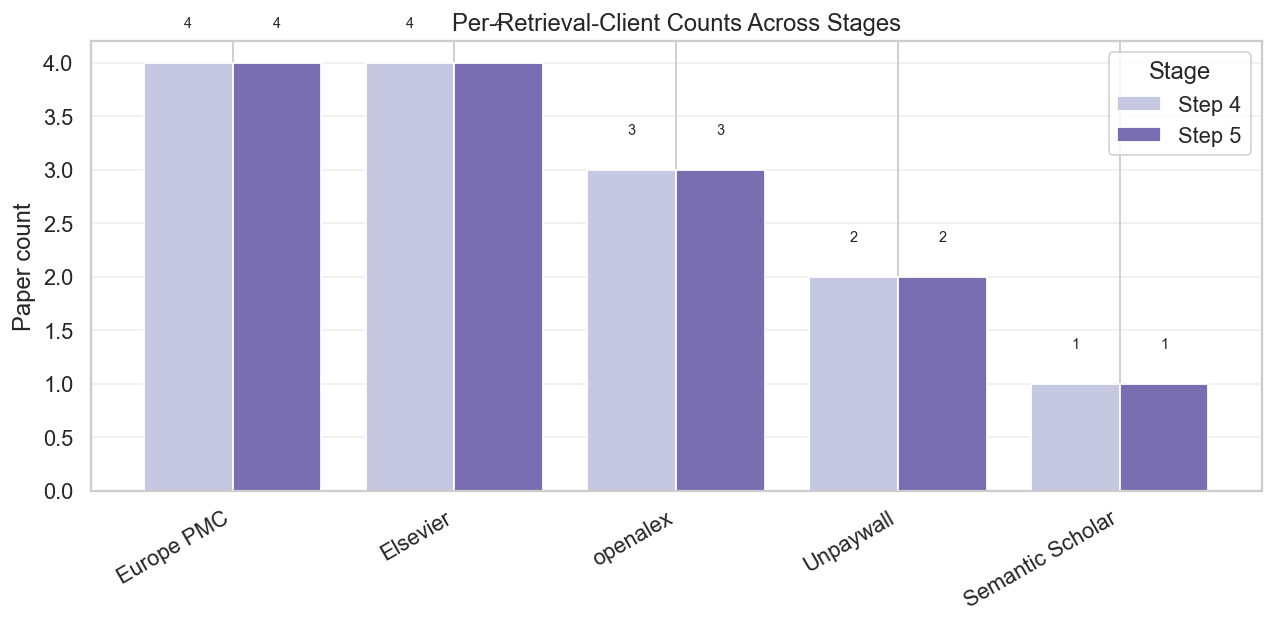

In [38]:
# --- Per-retrieval-client counts: grouped bar chart (Stages 4-6) ---
def _count_by_retrieval_client(records: list[dict]) -> dict[str, int]:
    out = defaultdict(int)
    for p in records:
        cli = p.get("ft_retrieved_by")
        if cli:
            out[CLIENT_LABELS.get(cli, cli)] += 1
    return dict(out)


stage_client_records = []
if "records_step4" in globals():
    stage_client_records.append(("Step 4", records_step4))
if "records_step5" in globals():
    stage_client_records.append(("Step 5", records_step5))
if "records_step6" in globals():  # optional future stage
    stage_client_records.append(("Step 6", records_step6))

if not stage_client_records:
    print("No stage records found for retrieval-client funnel.")
else:
    counts_by_client_stage = {
        lbl: _count_by_retrieval_client(recs) for lbl, recs in stage_client_records
    }

    clients = sorted(
        {c for d in counts_by_client_stage.values() for c in d},
        key=lambda c: -sum(d.get(c, 0) for d in counts_by_client_stage.values()),
    )

    df_funnel_client = (
        pd.DataFrame(counts_by_client_stage).reindex(clients).fillna(0).astype(int)
    )

    if df_funnel_client.empty:
        print("No retrieval-client labels were found across selected stages.")
    else:
        display(df_funnel_client)

        stage_cols = list(df_funnel_client.columns)
        n_clients = len(df_funnel_client)
        n_stages_local = len(stage_cols)
        bar_w = 0.8 / max(n_stages_local, 1)
        x = np.arange(n_clients)
        colors = sns.color_palette("Purples", n_stages_local)

        fig, ax = plt.subplots(figsize=(max(10, n_clients * 1.4), 5))
        for i, (col, color) in enumerate(zip(stage_cols, colors)):
            bars = ax.bar(
                x + i * bar_w,
                df_funnel_client[col].values,
                width=bar_w,
                label=col,
                color=color,
                edgecolor="white",
            )
            for b in bars:
                h = b.get_height()
                if h > 0:
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h + 0.3,
                        f"{int(h)}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

        ax.set_xticks(x + bar_w * (n_stages_local - 1) / 2)
        ax.set_xticklabels(df_funnel_client.index, rotation=30, ha="right")
        ax.set_ylabel("Paper count")
        ax.set_title("Per-Retrieval-Client Counts Across Stages")
        ax.legend(title="Stage")
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

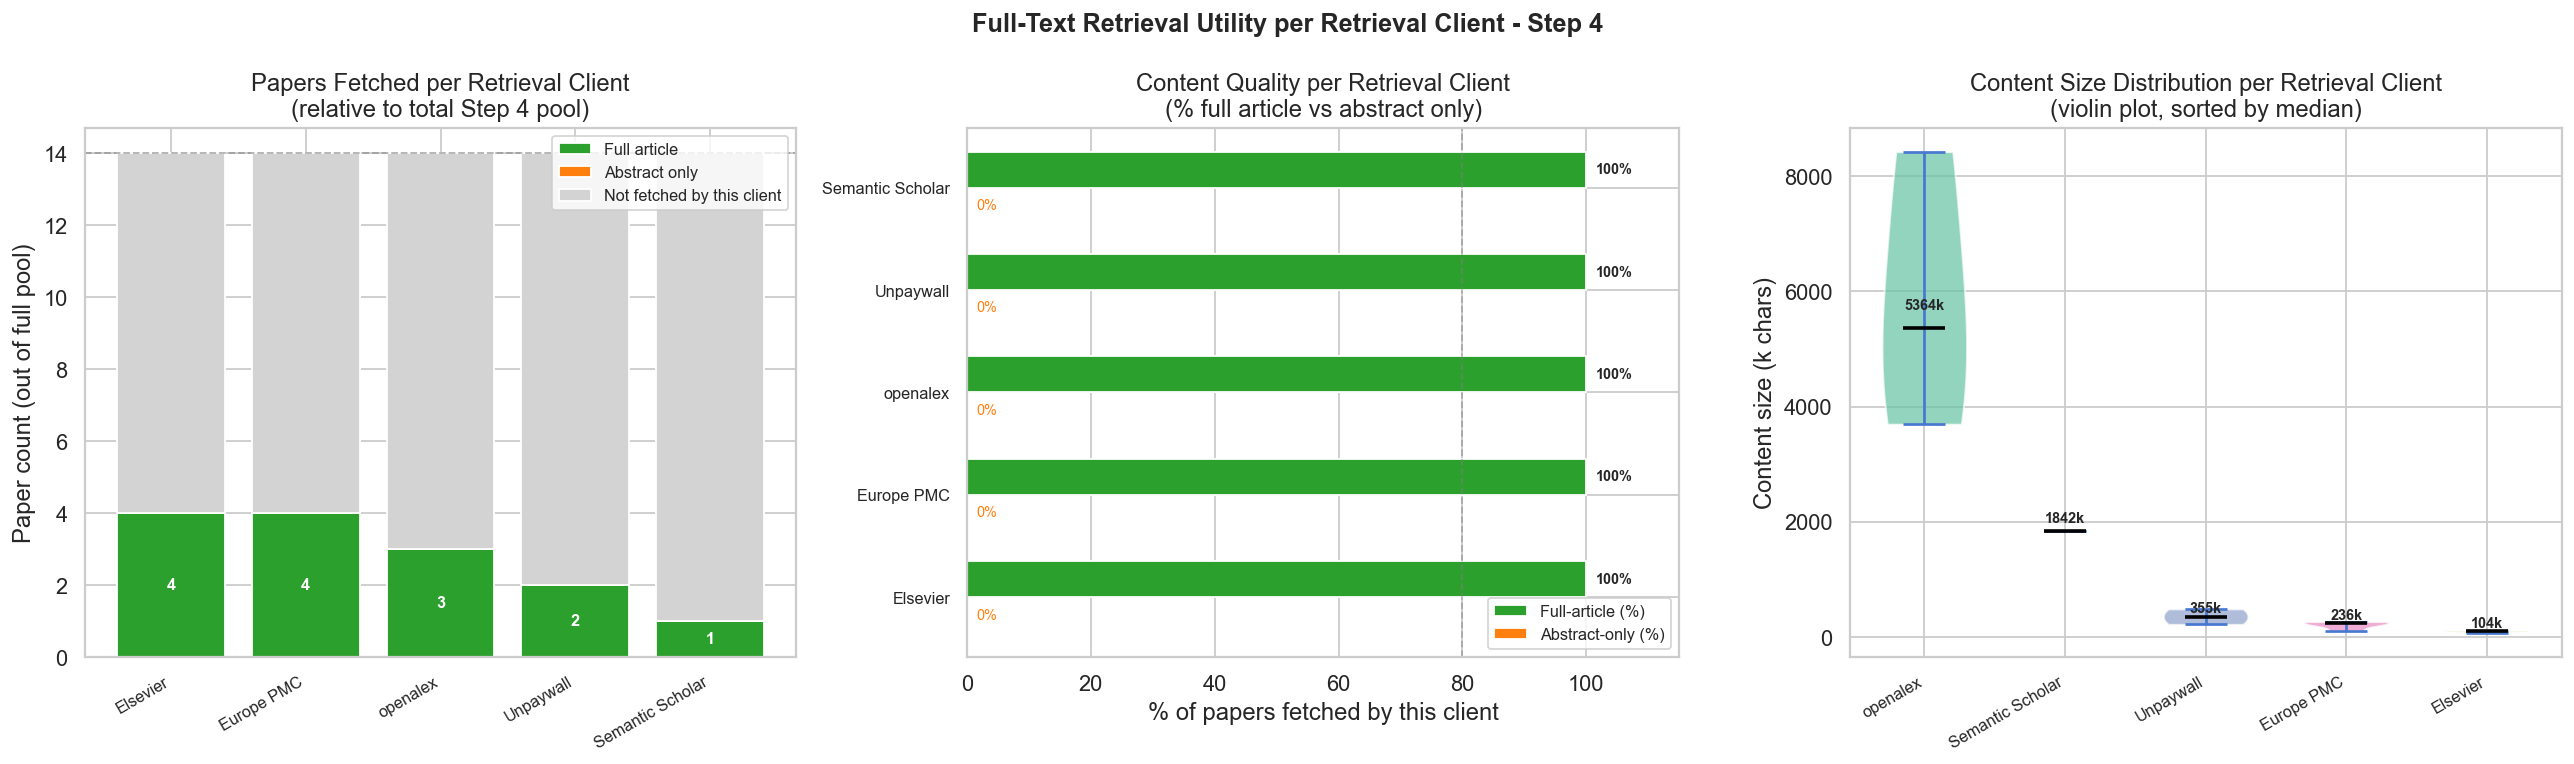

Highest pool coverage   : Elsevier  (28.6%, 4 papers)
Highest full-article %  : Elsevier  (100.0%)
Largest median content  : openalex  (5364.2k chars)


In [39]:
if df_ft_client.empty:
    print("No retrieval-client distribution to plot for Section 10.")
else:
    _client_order_ft = df_ft_client[
        "Client"
    ].tolist()  # sorted by papers fetched (desc)
    _n_clients = len(_client_order_ft)
    _palette_ft = sns.color_palette("Set2", _n_clients)

    fig_ftc, axes_ftc = plt.subplots(1, 3, figsize=(20, 6))
    fig_ftc.suptitle(
        "Full-Text Retrieval Utility per Retrieval Client - Step 4",
        fontsize=14,
        fontweight="bold",
    )

    # --- Plot 1: Stacked bar - full-article vs abstract-only vs not fetched ---
    ax1 = axes_ftc[0]
    _x = np.arange(_n_clients)

    # Build contributions relative to total pool
    _n_full_arr = (
        df_ft_client.set_index("Client")
        .reindex(_client_order_ft)["Full-article"]
        .values
    )
    _n_abst_arr = (
        df_ft_client.set_index("Client")
        .reindex(_client_order_ft)["Abstract-only"]
        .values
    )
    _pool_arr = np.full(_n_clients, _n_pool_ft)
    _n_none_arr = _pool_arr - _n_full_arr - _n_abst_arr

    b1 = ax1.bar(
        _x, _n_full_arr, color="#2ca02c", label="Full article", edgecolor="white"
    )
    b2 = ax1.bar(
        _x,
        _n_abst_arr,
        bottom=_n_full_arr,
        color="#ff7f0e",
        label="Abstract only",
        edgecolor="white",
    )
    b3 = ax1.bar(
        _x,
        _n_none_arr,
        bottom=_n_full_arr + _n_abst_arr,
        color="#d3d3d3",
        label="Not fetched by this client",
        edgecolor="white",
    )

    for bar, val in zip(b1, _n_full_arr):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                val / 2,
                str(int(val)),
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
    for bar, bot, val in zip(b2, _n_full_arr, _n_abst_arr):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                str(int(val)),
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )

    ax1.set_xticks(_x)
    ax1.set_xticklabels(_client_order_ft, rotation=30, ha="right", fontsize=9)
    ax1.set_ylabel("Paper count (out of full pool)")
    ax1.set_title(
        "Papers Fetched per Retrieval Client\n(relative to total Step 4 pool)"
    )
    ax1.legend(fontsize=9, loc="upper right")
    ax1.axhline(
        _n_pool_ft,
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Pool size",
    )

    # --- Plot 2: Full-article % and Abstract-only % horizontal grouped bars ---
    ax2 = axes_ftc[1]
    _df_sorted_cv = df_ft_client.sort_values("Full-article (%)", ascending=True)
    _y = np.arange(len(_df_sorted_cv))
    _bh = 0.35
    _bars_f = ax2.barh(
        _y + _bh / 2,
        _df_sorted_cv["Full-article (%)"],
        _bh,
        color="#2ca02c",
        label="Full-article (%)",
        edgecolor="white",
    )
    _bars_a = ax2.barh(
        _y - _bh / 2,
        _df_sorted_cv["Abstract-only (%)"],
        _bh,
        color="#ff7f0e",
        label="Abstract-only (%)",
        edgecolor="white",
    )
    ax2.set_yticks(_y)
    ax2.set_yticklabels(_df_sorted_cv["Client"], fontsize=9)
    ax2.set_xlabel("% of papers fetched by this client")
    ax2.set_title(
        "Content Quality per Retrieval Client\n(% full article vs abstract only)"
    )
    ax2.set_xlim(0, 115)
    ax2.legend(fontsize=9)
    ax2.axvline(80, color="grey", linestyle="--", linewidth=1, alpha=0.5)
    for bar, v in zip(_bars_f, _df_sorted_cv["Full-article (%)"]):
        ax2.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.0f}%",
            va="center",
            fontsize=8,
            fontweight="bold",
        )
    for bar, v in zip(_bars_a, _df_sorted_cv["Abstract-only (%)"]):
        ax2.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.0f}%",
            va="center",
            fontsize=8,
            color="#ff7f0e",
        )

    # --- Plot 3: Median content size violin plot ---
    ax3 = axes_ftc[2]
    _content_by_client: dict[str, list[float]] = {}
    for _p in step4_papers:
        _rcli = _p.get("ft_retrieved_by")
        if not _rcli or not _p.get("full_text"):
            continue
        _lbl = CLIENT_LABELS.get(_rcli, _rcli)
        _ft = _p.get("full_text") or {}
        _sz = len((_ft.get("content") or "")) / 1000
        _content_by_client.setdefault(_lbl, []).append(_sz)

    _cli_median_order = sorted(
        _content_by_client.keys(),
        key=lambda c: float(np.median(_content_by_client[c])),
        reverse=True,
    )
    _violin_data = [_content_by_client[c] for c in _cli_median_order]
    _vp = ax3.violinplot(
        _violin_data,
        positions=range(len(_cli_median_order)),
        showmedians=True,
        widths=0.6,
    )

    for _body, _color in zip(_vp["bodies"], _palette_ft[: len(_cli_median_order)]):
        _body.set_facecolor(_color)
        _body.set_alpha(0.7)
    _vp["cmedians"].set_color("black")
    _vp["cmedians"].set_linewidth(2)

    ax3.set_xticks(range(len(_cli_median_order)))
    ax3.set_xticklabels(_cli_median_order, rotation=30, ha="right", fontsize=9)
    ax3.set_ylabel("Content size (k chars)")
    ax3.set_title(
        "Content Size Distribution per Retrieval Client\n(violin plot, sorted by median)"
    )
    for i, _c in enumerate(_cli_median_order):
        _med_v = np.median(_content_by_client[_c])
        ax3.text(
            i,
            _med_v + _med_v * 0.05,
            f"{_med_v:.0f}k",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

    # --- Summary ---
    _best_coverage = df_ft_client.sort_values(
        "Pool coverage (%)", ascending=False
    ).iloc[0]
    _best_quality = df_ft_client.sort_values("Full-article (%)", ascending=False).iloc[
        0
    ]
    _best_size = df_ft_client.sort_values(
        "Median content (k ch)", ascending=False
    ).iloc[0]
    print(
        f"Highest pool coverage   : {_best_coverage['Client']}"
        f"  ({_best_coverage['Pool coverage (%)']:.1f}%,"
        f" {int(_best_coverage['Papers fetched'])} papers)"
    )
    print(
        f"Highest full-article %  : {_best_quality['Client']}"
        f"  ({_best_quality['Full-article (%)']:.1f}%)"
    )
    print(
        f"Largest median content  : {_best_size['Client']}"
        f"  ({_best_size['Median content (k ch)']:.1f}k chars)"
    )

## 11. Full-Text Retrieval Speed — Step 4 Response Times

This section analyses the **wall-clock time** spent by each retrieval client to fetch full text during Step 4. The field `ft_response_time_ms` (milliseconds per `fetch_full_text()` call) and `ft_retrieved_by` (the client that succeeded) are read directly from `step4_fulltext_raw_papers.json`.

| Metric | Description |
|---|---|
| **Retrieval client** | Client that successfully obtained full text (`ft_retrieved_by`) |
| **Response time (ms)** | Time from request start to full response for that client |
| **Content size (chars)** | Length of the retrieved text string |
| **Coverage** | Fraction of the pool for which this client returned a non-empty result |

Only the **winning** call (the one that returned text) is timed; failed or skipped attempts are not recorded in this field.


In [40]:
# --- Load Step 4 data ---
with open(STEP4, encoding="utf-8") as fh:
    step4_papers = json.load(fh)

# --- Extract full-text timing records ---
ft_timing_rows = []
for p in step4_papers:
    rt = p.get("ft_response_time_ms")
    cli = p.get("ft_retrieved_by")
    if rt is None or not cli or not p.get("full_text"):
        continue

    content = ""
    ft = p.get("full_text")
    if isinstance(ft, dict):
        content = ft.get("content", "") or ""

    ft_timing_rows.append(
        {
            "client": cli,
            "response_time_ms": float(rt),
            "content_chars": len(content),
            "is_abstract_only": (ft or {}).get("is_abstract_only", False)
            if ft
            else None,
            "source": p.get("source", "unknown"),
        }
    )

# --- Pool size and overall coverage ---
n_pool = len(step4_papers)
n_with_timing = len(ft_timing_rows)
print(f"Step 4 pool size            : {n_pool}")
print(
    f"Papers with ft timing data  : {n_with_timing}  ({(n_with_timing / n_pool * 100) if n_pool else 0:.1f}%)"
)
print(
    f"Papers without FT timing    : {n_pool - n_with_timing}  (no full text or pre-timing data)\n"
)

if not ft_timing_rows:
    df_ft_speed = pd.DataFrame(
        columns=[
            "client",
            "response_time_ms",
            "content_chars",
            "is_abstract_only",
            "source",
            "response_time_s",
        ]
    )
    df_speed_stats = pd.DataFrame(
        columns=[
            "Client",
            "Papers",
            "Coverage (%)",
            "Median (s)",
            "Mean (s)",
            "P25 (s)",
            "P75 (s)",
            "Max (s)",
            "Median content (k chars)",
        ]
    )
    print(
        "No ft_response_time_ms records were found in Step 4 for successful retrievals."
    )
else:
    df_ft_speed = pd.DataFrame(ft_timing_rows)
    df_ft_speed["response_time_s"] = df_ft_speed["response_time_ms"] / 1000

    # --- Per-client summary statistics ---
    stats_rows = []
    for cli, grp in df_ft_speed.groupby("client"):
        rt = grp["response_time_ms"]
        chars = grp["content_chars"]
        stats_rows.append(
            {
                "Client": CLIENT_LABELS.get(cli, cli),
                "Papers": len(grp),
                "Coverage (%)": round(len(grp) / n_pool * 100, 1) if n_pool else 0.0,
                "Median (s)": round(rt.median() / 1000, 1),
                "Mean (s)": round(rt.mean() / 1000, 1),
                "P25 (s)": round(rt.quantile(0.25) / 1000, 1),
                "P75 (s)": round(rt.quantile(0.75) / 1000, 1),
                "Max (s)": round(rt.max() / 1000, 1),
                "Median content (k chars)": round(chars.median() / 1000, 1),
            }
        )

    df_speed_stats = (
        pd.DataFrame(stats_rows).sort_values("Median (s)").reset_index(drop=True)
    )

    print("Per-client full-text retrieval speed summary:")
    display(
        df_speed_stats.style.background_gradient(
            subset=["Median (s)", "Mean (s)", "Max (s)"], cmap="RdYlGn_r", axis=0
        )
        .background_gradient(
            subset=["Coverage (%)"], cmap="Blues", vmin=0, vmax=100, axis=0
        )
        .format(
            {
                "Coverage (%)": "{:.1f}%",
                "Median (s)": "{:.1f}",
                "Mean (s)": "{:.1f}",
                "P25 (s)": "{:.1f}",
                "P75 (s)": "{:.1f}",
                "Max (s)": "{:.1f}",
                "Median content (k chars)": "{:.1f}k",
            }
        )
        .set_caption("Full-text retrieval speed per client - Step 4 (lower is faster)")
    )

Step 4 pool size            : 14
Papers with ft timing data  : 14  (100.0%)
Papers without FT timing    : 0  (no full text or pre-timing data)

Per-client full-text retrieval speed summary:


,Client,Papers,Coverage (%),Median (s),Mean (s),P25 (s),P75 (s),Max (s),Median content (k chars)
0,Elsevier,4,28.6%,1.0,1.2,0.9,1.3,1.9,103.6k
1,Europe PMC,4,28.6%,1.6,1.4,1.3,1.7,1.8,235.7k
2,Semantic Scholar,1,7.1%,2.9,2.9,2.9,2.9,2.9,1842.0k
3,Unpaywall,2,14.3%,3.0,3.0,2.9,3.2,3.3,354.7k
4,openalex,3,21.4%,3.4,3.9,3.1,4.4,5.5,5364.2k


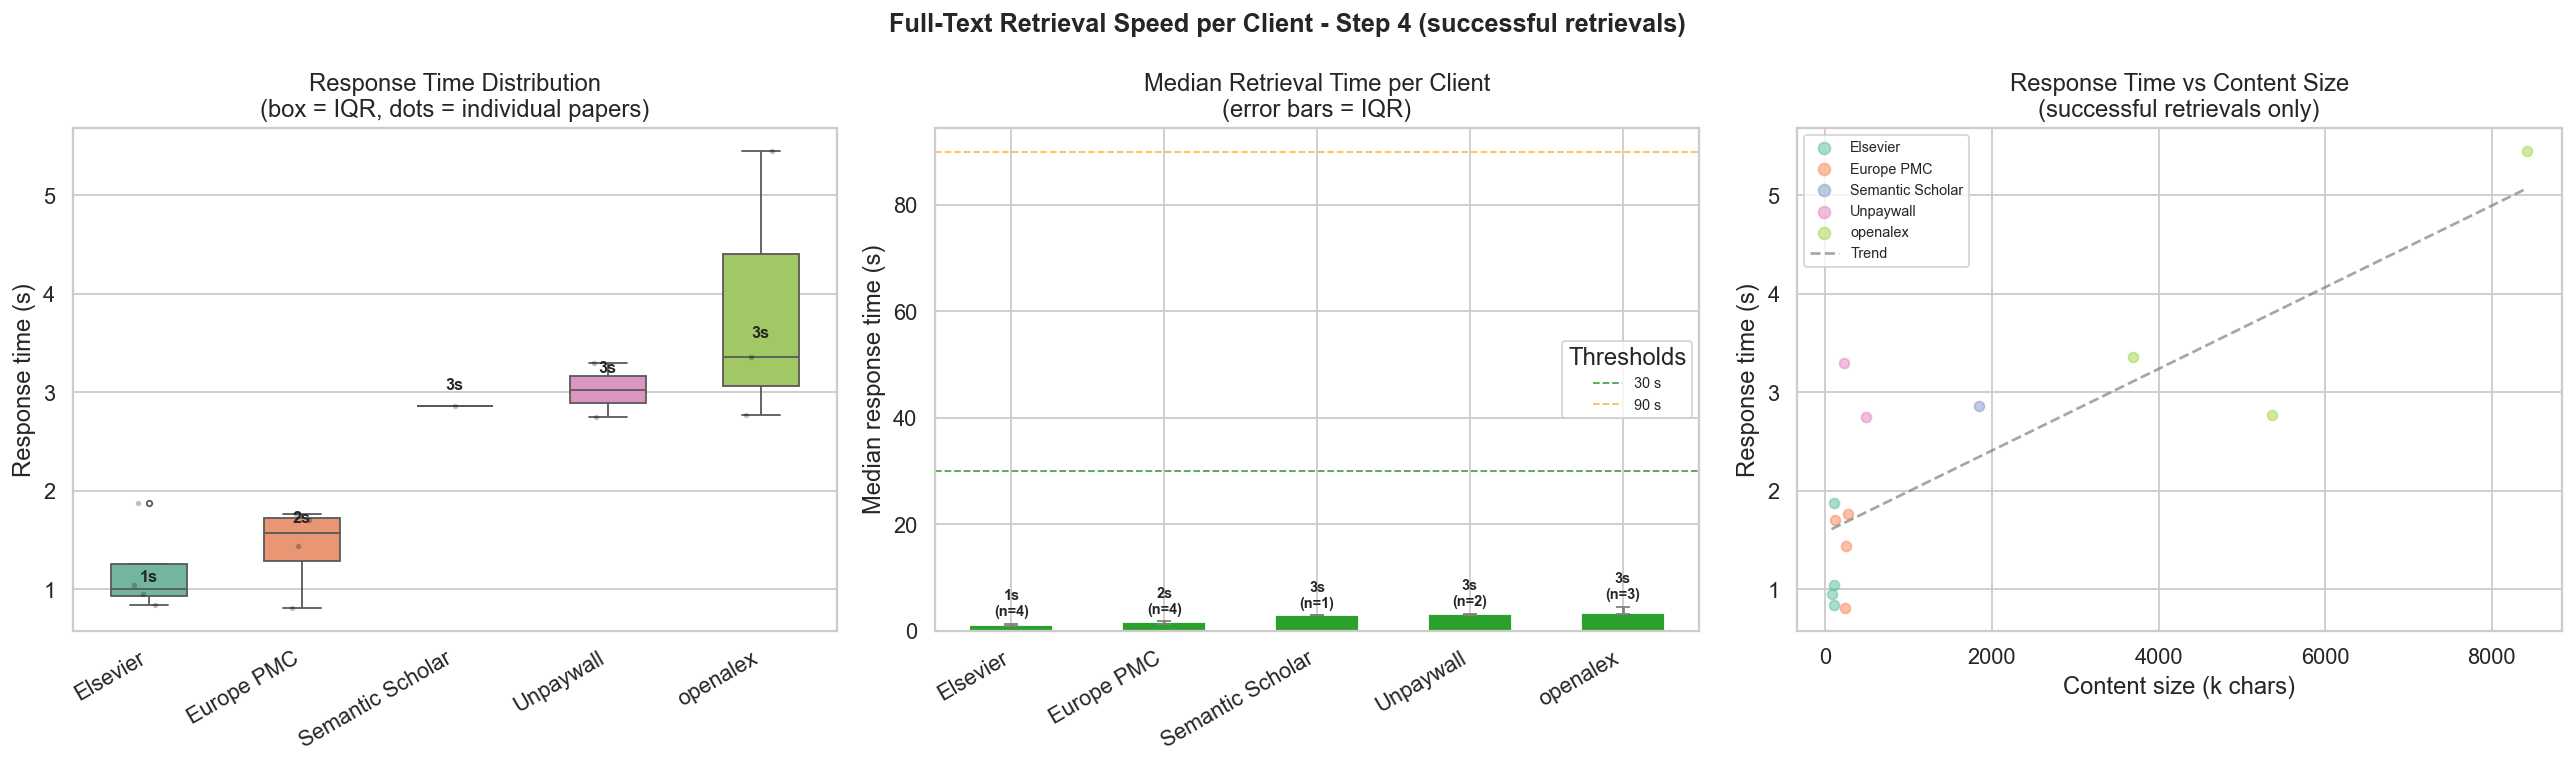


Fastest client : Elsevier  (median 1.0s, 4 papers)
Slowest client : openalex  (median 3.4s, 3 papers)
Speed-up factor: 3.4x
Note: this section uses observed timings from successful retrievals (winner client only).


In [41]:
if df_ft_speed.empty or df_speed_stats.empty:
    print("No timing distribution to plot for Section 11.")
else:
    # --- Map raw client names to display labels ---
    df_ft_speed = df_ft_speed.copy()
    df_ft_speed["Client"] = df_ft_speed["client"].map(lambda s: CLIENT_LABELS.get(s, s))

    client_order = df_speed_stats.sort_values("Median (s)")["Client"].tolist()
    palette_speed = sns.color_palette("Set2", len(client_order))

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(
        "Full-Text Retrieval Speed per Client - Step 4 (successful retrievals)",
        fontsize=14,
        fontweight="bold",
    )

    # --- Plot 1: Box + strip plot ---
    ax1 = axes[0]
    sns.boxplot(
        data=df_ft_speed,
        x="Client",
        y="response_time_s",
        order=client_order,
        palette=palette_speed,
        width=0.5,
        fliersize=3,
        ax=ax1,
    )
    sns.stripplot(
        data=df_ft_speed,
        x="Client",
        y="response_time_s",
        order=client_order,
        color="black",
        alpha=0.25,
        size=3,
        jitter=True,
        ax=ax1,
    )

    medians_s = df_ft_speed.groupby("Client")["response_time_s"].median()
    for i, cli in enumerate(client_order):
        if cli in medians_s.index:
            ax1.text(
                i,
                medians_s[cli] + medians_s[cli] * 0.05,
                f"{medians_s[cli]:.0f}s",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )
    ax1.set_title("Response Time Distribution\n(box = IQR, dots = individual papers)")
    ax1.set_xlabel("")
    ax1.set_ylabel("Response time (s)")
    ax1.set_xticklabels(client_order, rotation=30, ha="right")

    # --- Plot 2: Median response time with IQR error bars ---
    ax2 = axes[1]
    grp = df_ft_speed.groupby("Client")["response_time_s"]
    med = grp.median().reindex(client_order)
    p25 = grp.quantile(0.25).reindex(client_order)
    p75 = grp.quantile(0.75).reindex(client_order)
    yerr_low = (med - p25).clip(lower=0)
    yerr_high = (p75 - med).clip(lower=0)

    bar_colors = [
        "#2ca02c" if v < 30 else "#ff7f0e" if v < 90 else "#d62728" for v in med.values
    ]
    ax2.bar(
        range(len(client_order)),
        med.values,
        color=bar_colors,
        width=0.55,
        edgecolor="white",
        yerr=[yerr_low.values, yerr_high.values],
        capsize=4,
        error_kw={"elinewidth": 1.5, "ecolor": "grey"},
    )

    papers_by_client = df_speed_stats.set_index("Client").reindex(client_order)[
        "Papers"
    ]
    for i, (v, n) in enumerate(zip(med.values, papers_by_client)):
        ax2.text(
            i,
            v + yerr_high.values[i] + 1,
            f"{v:.0f}s\n(n={int(n)})",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )
    ax2.set_xticks(range(len(client_order)))
    ax2.set_xticklabels(client_order, rotation=30, ha="right")
    ax2.set_ylabel("Median response time (s)")
    ax2.set_title("Median Retrieval Time per Client\n(error bars = IQR)")
    ax2.axhline(30, color="green", linestyle="--", linewidth=1, alpha=0.7, label="30 s")
    ax2.axhline(
        90, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="90 s"
    )
    ax2.legend(fontsize=8, title="Thresholds")

    # --- Plot 3: Scatter - response time vs content size ---
    ax3 = axes[2]
    for cli, color in zip(client_order, palette_speed):
        sub = df_ft_speed[df_ft_speed["Client"] == cli]
        ax3.scatter(
            sub["content_chars"] / 1000,
            sub["response_time_s"],
            label=cli,
            alpha=0.55,
            s=30,
            color=color,
        )

    from numpy.polynomial.polynomial import polyfit as _polyfit

    if len(df_ft_speed) > 2:
        _x = df_ft_speed["content_chars"].values / 1000
        _y = df_ft_speed["response_time_s"].values
        _mask = np.isfinite(_x) & np.isfinite(_y)
        if _mask.sum() > 2:
            _c, _m = _polyfit(_x[_mask], _y[_mask], 1)
            _xs = np.linspace(_x[_mask].min(), _x[_mask].max(), 100)
            ax3.plot(
                _xs,
                _c + _m * _xs,
                color="grey",
                linewidth=1.5,
                linestyle="--",
                label="Trend",
                alpha=0.7,
            )

    ax3.set_xlabel("Content size (k chars)")
    ax3.set_ylabel("Response time (s)")
    ax3.set_title("Response Time vs Content Size\n(successful retrievals only)")
    ax3.legend(fontsize=8, markerscale=1.2, loc="upper left")

    plt.tight_layout()
    plt.show()

    # --- Textual summary ---
    fastest = df_speed_stats.iloc[0]
    slowest = df_speed_stats.iloc[-1]
    print(
        f"\nFastest client : {fastest['Client']}"
        f"  (median {fastest['Median (s)']}s, {int(fastest['Papers'])} papers)"
    )
    print(
        f"Slowest client : {slowest['Client']}"
        f"  (median {slowest['Median (s)']}s, {int(slowest['Papers'])} papers)"
    )
    print(
        f"Speed-up factor: {slowest['Median (s)'] / max(fastest['Median (s)'], 0.1):.1f}x"
    )
    print(
        "Note: this section uses observed timings from successful retrievals (winner client only)."
    )

In [42]:
# --- 12. Extra: intento total, éxito y tiempo por API de extracción (desde CSV de telemetría) ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

telemetry_candidates = [
    BASE / "notebooks" / "step4_attempt_telemetry_summary.csv",
    Path("notebooks/step4_attempt_telemetry_summary.csv"),
    Path("step4_attempt_telemetry_summary.csv"),
]

summary_path = next((p for p in telemetry_candidates if Path(p).exists()), None)
if summary_path is None:
    raise FileNotFoundError(
        "No se encontró step4_attempt_telemetry_summary.csv. Ejecuta primero notebooks/generate_step4_attempt_telemetry.py"
    )

df_tel = pd.read_csv(summary_path)
if df_tel.empty:
    raise ValueError("El CSV de telemetría está vacío.")

required_cols = [
    "client_label",
    "attempts_total",
    "success",
    "attempted_before_success_unlogged",
    "attempted_no_success_unlogged",
    "not_attempted_after_success",
    "mean_success_ms",
    "median_success_ms",
    "total_success_ms",
]
missing = [c for c in required_cols if c not in df_tel.columns]
if missing:
    raise ValueError(f"Faltan columnas esperadas en el CSV: {missing}")

for c in [
    "attempts_total",
    "success",
    "attempted_before_success_unlogged",
    "attempted_no_success_unlogged",
    "not_attempted_after_success",
    "mean_success_ms",
    "median_success_ms",
    "total_success_ms",
]:
    df_tel[c] = pd.to_numeric(df_tel[c], errors="coerce")

# Métricas derivadas
df_tel["success_rate_pct"] = (
    (df_tel["success"] / df_tel["attempts_total"]).replace([np.inf, -np.inf], np.nan)
    * 100
).fillna(0.0)
df_tel["failed_or_wasted_attempts"] = (
    df_tel["attempted_before_success_unlogged"]
    + df_tel["attempted_no_success_unlogged"]
).fillna(0.0)
df_tel["failed_or_wasted_pct"] = (
    (df_tel["failed_or_wasted_attempts"] / df_tel["attempts_total"]).replace(
        [np.inf, -np.inf], np.nan
    )
    * 100
).fillna(0.0)
df_tel["median_success_s"] = df_tel["median_success_ms"] / 1000.0
df_tel["total_success_s"] = df_tel["total_success_ms"] / 1000.0

# Orden para tablas y gráficos
df_tel = df_tel.sort_values(
    ["success_rate_pct", "success"], ascending=[False, False]
).reset_index(drop=True)

summary_cols = [
    "client_label",
    "attempts_total",
    "success",
    "success_rate_pct",
    "failed_or_wasted_attempts",
    "failed_or_wasted_pct",
    "median_success_s",
    "total_success_s",
]

print(f"CSV usado: {summary_path}")
print("\nTelemetría agregada por API (Step 4, inferida por intento):")
display(
    df_tel[summary_cols]
    .rename(
        columns={
            "client_label": "API extracción",
            "attempts_total": "Intentos totales",
            "success": "Éxitos",
            "success_rate_pct": "Success rate (%)",
            "failed_or_wasted_attempts": "Intentos no exitosos",
            "failed_or_wasted_pct": "No exitosos (%)",
            "median_success_s": "Mediana éxito (s)",
            "total_success_s": "Tiempo total éxitos (s)",
        }
    )
    .style.background_gradient(
        subset=["Success rate (%)"], cmap="Greens", vmin=0, vmax=100
    )
    .background_gradient(subset=["No exitosos (%)"], cmap="Reds", vmin=0, vmax=100)
    .background_gradient(
        subset=["Mediana éxito (s)", "Tiempo total éxitos (s)"], cmap="YlOrRd"
    )
    .format(
        {
            "Success rate (%)": "{:.1f}%",
            "No exitosos (%)": "{:.1f}%",
            "Mediana éxito (s)": "{:.1f}",
            "Tiempo total éxitos (s)": "{:.1f}",
        }
    )
    .set_caption("Step 4 telemetry summary per extraction API")
)

# Gráfico compuesto de eficiencia
plot_df = df_tel.copy()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: tasas de éxito vs no-exitosos
ax1 = axes[0]
bw = 0.38
ax1.bar(
    x - bw / 2,
    plot_df["success_rate_pct"],
    width=bw,
    color="#55A868",
    label="Success rate (%)",
)
ax1.bar(
    x + bw / 2,
    plot_df["failed_or_wasted_pct"],
    width=bw,
    color="#C44E52",
    label="No exitosos (%)",
)
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["client_label"], rotation=30, ha="right")
ax1.set_ylabel("% sobre intentos")
ax1.set_title("Rendimiento por API (éxitos vs intentos no exitosos)")
ax1.set_ylim(0, 100)
ax1.legend()
for i, v in enumerate(plot_df["success_rate_pct"]):
    ax1.text(
        i - bw / 2, min(v + 1, 98), f"{v:.1f}%", ha="center", va="bottom", fontsize=8
    )
for i, v in enumerate(plot_df["failed_or_wasted_pct"]):
    ax1.text(
        i + bw / 2, min(v + 1, 98), f"{v:.1f}%", ha="center", va="bottom", fontsize=8
    )

# Plot 2: tiempo de éxito vs volumen de éxitos (sólo APIs con éxito temporizado)
ax2 = axes[1]
plot_scatter = plot_df[
    (plot_df["success"] > 0) & plot_df["median_success_s"].notna()
].copy()
if plot_scatter.empty:
    ax2.text(
        0.5, 0.5, "No hay APIs con éxito y tiempo registrado", ha="center", va="center"
    )
    ax2.set_axis_off()
else:
    sc = ax2.scatter(
        plot_scatter["median_success_s"],
        plot_scatter["success"],
        s=np.clip(plot_scatter["total_success_s"], 10, None) * 0.6,
        c=plot_scatter["success_rate_pct"],
        cmap="viridis",
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
    )
    for _, row in plot_scatter.iterrows():
        ax2.text(
            row["median_success_s"] + 0.1,
            row["success"] + 0.2,
            row["client_label"],
            fontsize=8,
        )
    ax2.set_xlabel("Mediana de tiempo en éxitos (s)")
    ax2.set_ylabel("Nº de éxitos")
    ax2.set_title("Trade-off: velocidad de éxito vs volumen de éxitos")
    cbar = plt.colorbar(sc, ax=ax2)
    cbar.set_label("Success rate (%)")

plt.tight_layout()
plt.show()

best = df_tel.sort_values(
    ["success_rate_pct", "median_success_s"], ascending=[False, True]
).iloc[0]
worst = df_tel.sort_values(
    ["failed_or_wasted_pct", "success"], ascending=[False, True]
).iloc[0]

print("\nResumen rápido:")
print(
    f"- Mejor balance: {best['client_label']} (success rate {best['success_rate_pct']:.1f}%, "
    f"mediana éxito {best['median_success_s']:.1f}s, éxitos {int(best['success'])})."
)
print(
    f"- Mayor fricción: {worst['client_label']} (no exitosos {worst['failed_or_wasted_pct']:.1f}%, "
    f"éxitos {int(worst['success'])})."
)
print(
    "Nota: la telemetría por intento es inferida; los tiempos sólo existen para éxitos persistidos."
)

FileNotFoundError: No se encontró step4_attempt_telemetry_summary.csv. Ejecuta primero notebooks/generate_step4_attempt_telemetry.py

In [ ]:
# --- 13. Tabla final: tiempo e intentos por API de extracción ---
from pathlib import Path
import numpy as np
import pandas as pd

telemetry_candidates = [
    BASE / "notebooks" / "step4_attempt_telemetry_summary.csv",
    Path("notebooks/step4_attempt_telemetry_summary.csv"),
    Path("step4_attempt_telemetry_summary.csv"),
]

summary_path = next((p for p in telemetry_candidates if Path(p).exists()), None)
if summary_path is None:
    raise FileNotFoundError(
        "No se encontró step4_attempt_telemetry_summary.csv. Ejecuta primero notebooks/generate_step4_attempt_telemetry.py"
    )

df_kpi = pd.read_csv(summary_path)
if df_kpi.empty:
    raise ValueError("El CSV de telemetría está vacío.")

required_cols = [
    "client_label",
    "success",
    "attempted_before_success_unlogged",
    "attempted_no_success_unlogged",
    "total_success_ms",
]
missing_cols = [c for c in required_cols if c not in df_kpi.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en el CSV: {missing_cols}")

for col in [
    "success",
    "attempted_before_success_unlogged",
    "attempted_no_success_unlogged",
    "total_success_ms",
]:
    df_kpi[col] = pd.to_numeric(df_kpi[col], errors="coerce").fillna(0.0)

# Intentos reales por API: éxitos + intentos fallidos/inferidos ejecutados
df_kpi["numero_intentos"] = (
    df_kpi["success"]
    + df_kpi["attempted_before_success_unlogged"]
    + df_kpi["attempted_no_success_unlogged"]
).astype(int)
df_kpi["numero_intentos_exitosos"] = df_kpi["success"].astype(int)

# El tiempo disponible en CSV corresponde a éxitos persistidos
df_kpi["tiempo_total_busqueda_s"] = df_kpi["total_success_ms"] / 1000.0

df_kpi["tiempo_medio_por_intento_s"] = np.where(
    df_kpi["numero_intentos"] > 0,
    df_kpi["tiempo_total_busqueda_s"] / df_kpi["numero_intentos"],
    np.nan,
)
df_kpi["tiempo_medio_por_intento_exitoso_s"] = np.where(
    df_kpi["numero_intentos_exitosos"] > 0,
    df_kpi["tiempo_total_busqueda_s"] / df_kpi["numero_intentos_exitosos"],
    np.nan,
)

tabla_final = (
    df_kpi[
        [
            "client_label",
            "tiempo_total_busqueda_s",
            "numero_intentos",
            "tiempo_medio_por_intento_s",
            "numero_intentos_exitosos",
            "tiempo_medio_por_intento_exitoso_s",
        ]
    ]
    .rename(
        columns={
            "client_label": "API",
            "tiempo_total_busqueda_s": "Tiempo total de búsqueda (s)",
            "numero_intentos": "Número de intentos",
            "tiempo_medio_por_intento_s": "Tiempo medio por intento (s)",
            "numero_intentos_exitosos": "Número de intentos exitosos",
            "tiempo_medio_por_intento_exitoso_s": "Tiempo medio por intento exitoso (s)",
        }
    )
    .sort_values("Número de intentos", ascending=False)
    .reset_index(drop=True)
)

print(f"CSV usado: {summary_path}")
display(
    tabla_final.style.background_gradient(
        subset=["Número de intentos", "Número de intentos exitosos"], cmap="Blues"
    )
    .background_gradient(subset=["Tiempo total de búsqueda (s)"], cmap="YlOrRd")
    .background_gradient(
        subset=["Tiempo medio por intento (s)", "Tiempo medio por intento exitoso (s)"],
        cmap="YlGnBu",
    )
    .format(
        {
            "Tiempo total de búsqueda (s)": "{:.1f}",
            "Tiempo medio por intento (s)": "{:.2f}",
            "Tiempo medio por intento exitoso (s)": "{:.2f}",
        }
    )
    .set_caption("KPIs de búsqueda por API de extracción (Step 4)")
)

print(
    "Nota: 'Número de intentos' ya no usa attempts_total; ahora usa intentos realmente ejecutados por API."
)
print(
    "Nota: el tiempo total proviene de tiempos registrados en éxitos persistidos del Step 4."
)

CSV usado: ..\notebooks\step4_attempt_telemetry_summary.csv


,API,Tiempo total de búsqueda (s),Número de intentos,Tiempo medio por intento (s),Número de intentos exitosos,Tiempo medio por intento exitoso (s)
0,Elsevier,32.6,69,0.47,12,2.71
1,Europe PMC,133.4,57,2.34,26,5.13
2,Semantic Scholar,113.5,31,3.66,2,56.75
3,PMC,0.0,31,0.00,0,nan
4,Unpaywall,140.9,29,4.86,7,20.12
5,OpenAlex,176.3,22,8.01,5,35.26


Nota: 'Número de intentos' ya no usa attempts_total; ahora usa intentos realmente ejecutados por API.
Nota: el tiempo total proviene de tiempos registrados en éxitos persistidos del Step 4.
